# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 51     |  |
| :-------------|:-------------|
| Kimi Hekmat| 6534759 |
| Frank de Kogel| 6582737 |
| Student naam 3| Student Studienummer 3 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Frank', 'Kimi']

## Opdracht 1: Planning.

| Planning Groep: 51     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | 12:30 |
| Mijlpaal 2 | 16:30 |
| groep aanwezig 1| 13:30 |
| groep aanwezig 2| 16:15 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 16:00-16:15 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [51]
Bij onze kalibratieopstelling meten we enkel de afstand heen (er is geen afstand terug)
<img src="kalibratie_echo.jpeg" width="400">

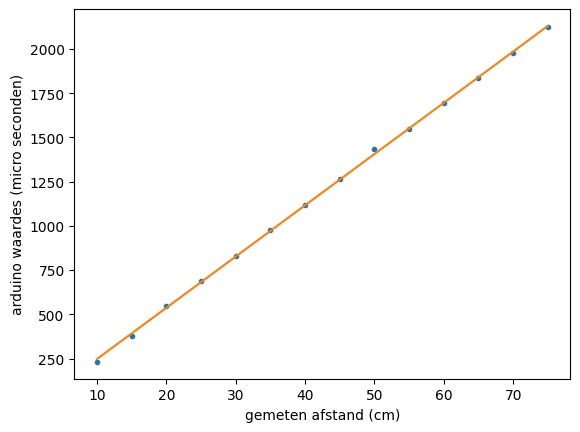

[ 28.97450549 -42.48791209]


In [3]:
# verwerk hier jullie kalibratiemetingen

fysiek = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75]) # afstanden in centimeters (voorkant vericale platen)
arduino = np.array([231, 378, 549, 687, 830, 975, 1119, 1266, 1433, 1548, 1693, 1837, 1977, 2122]) # Meettijden in microseconden

def fit(x, a, b):
    return a*x + b

vals, covs = curve_fit(fit, fysiek, arduino)
xtest = np.linspace(np.min(fysiek), np.max(fysiek), 500)
ytest = fit(xtest, *vals)

plt.figure()
plt.plot(fysiek, arduino, '.', label = 'meetdata')
plt.plot(xtest, ytest, label = 'fit')
plt.xlabel('gemeten afstand (cm)')
plt.ylabel('arduino waardes (micro seconden)')
plt.show()

print(vals)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.6
1   0  30   0  20  41.1
2  40   0  30   0  39.9
3  30   0  20   0  40.3


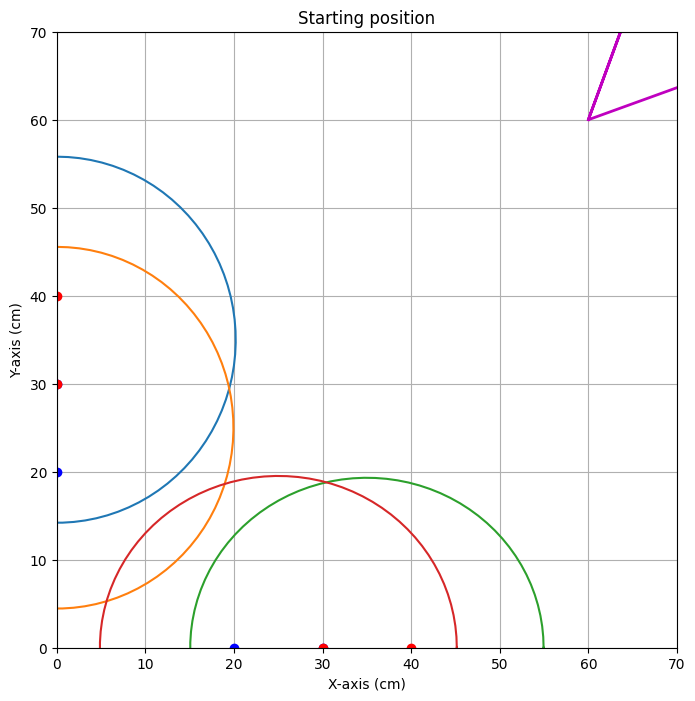


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.230


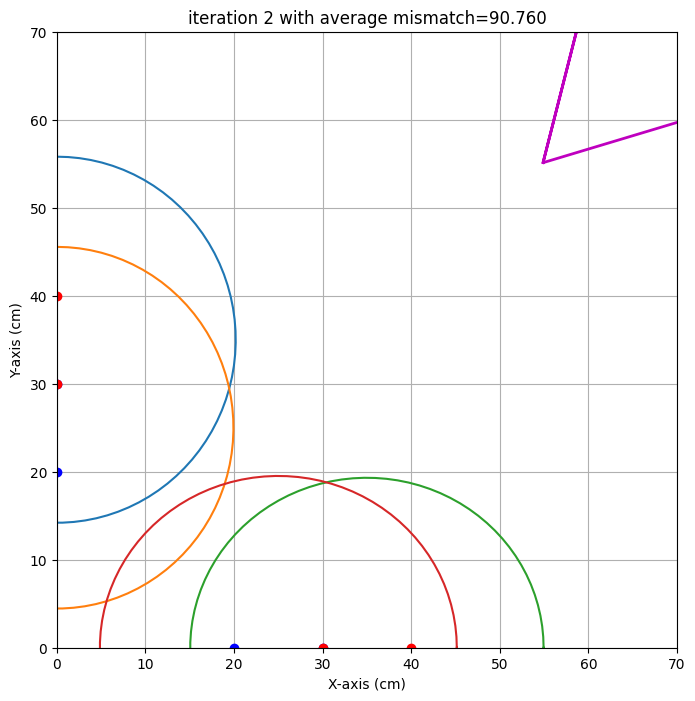

end iteration 2 with average mismatch=90.760


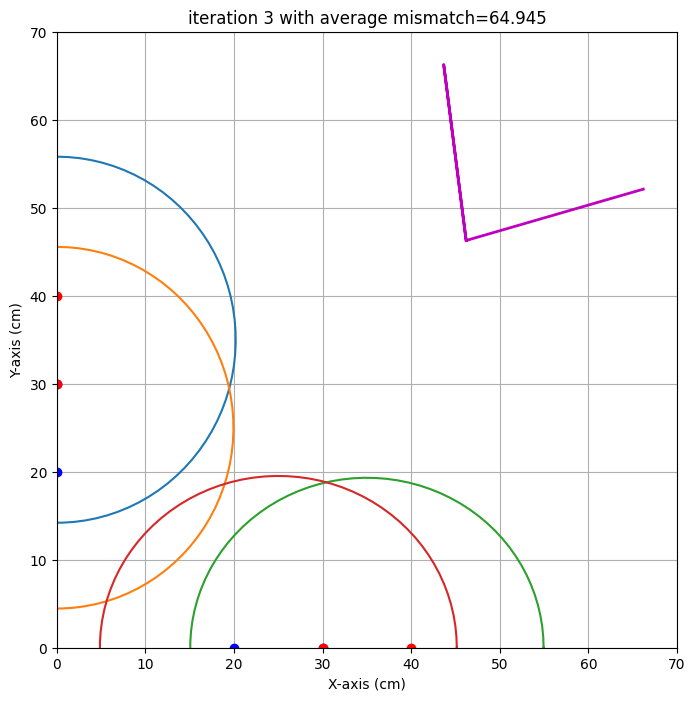

end iteration 3 with average mismatch=64.945


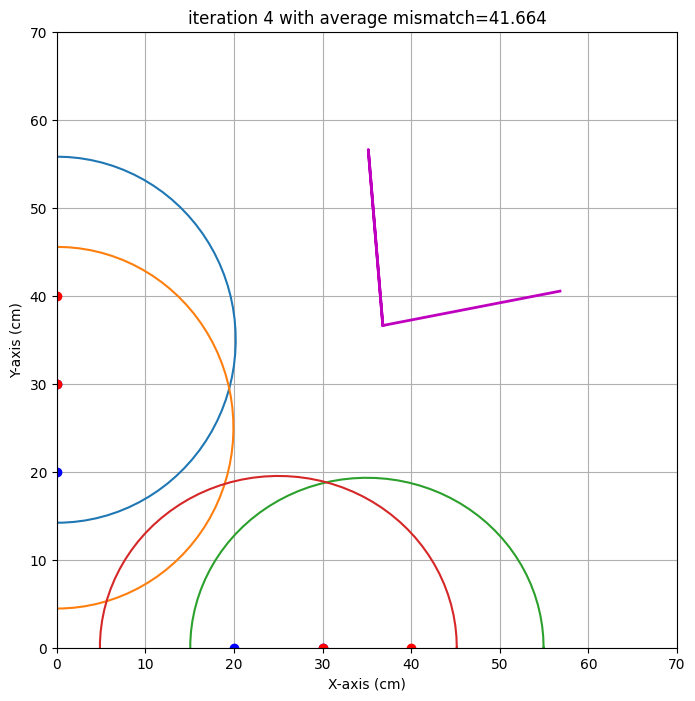

end iteration 4 with average mismatch=41.664


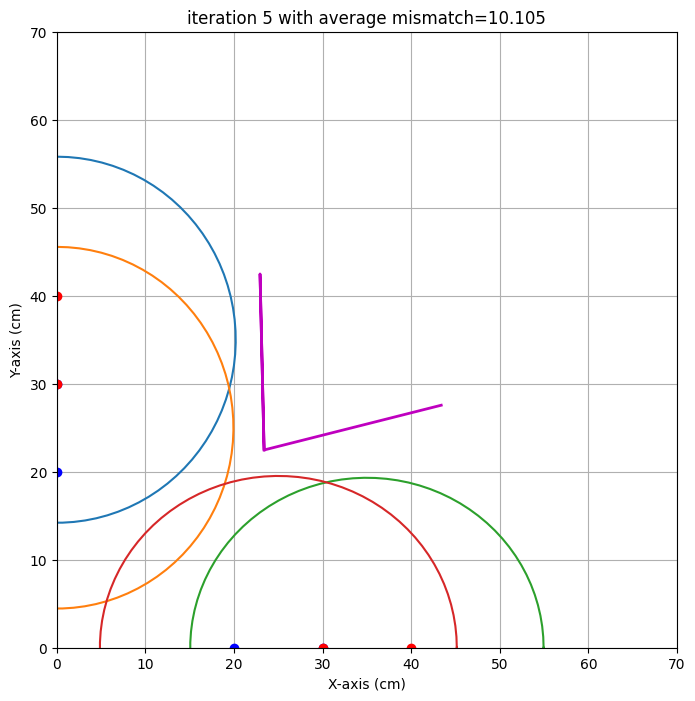

end iteration 5 with average mismatch=10.105


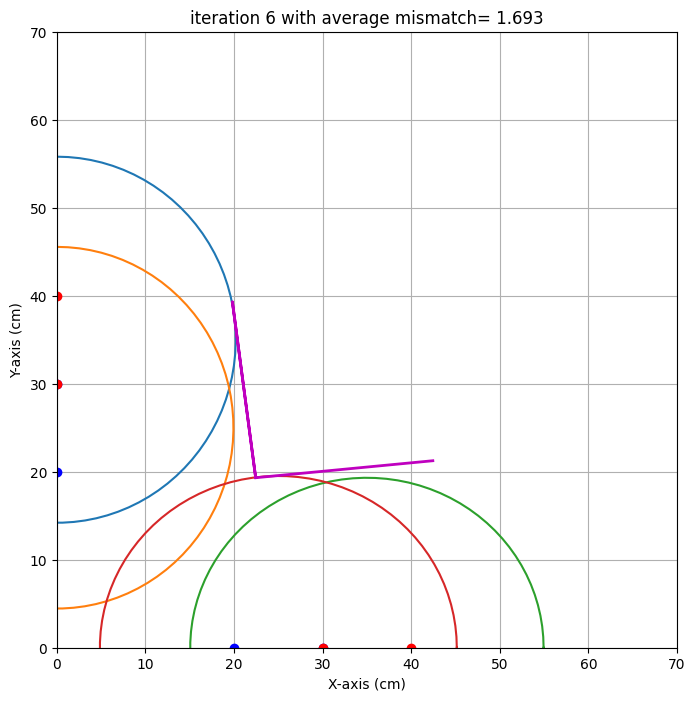

end iteration 6 with average mismatch= 1.693


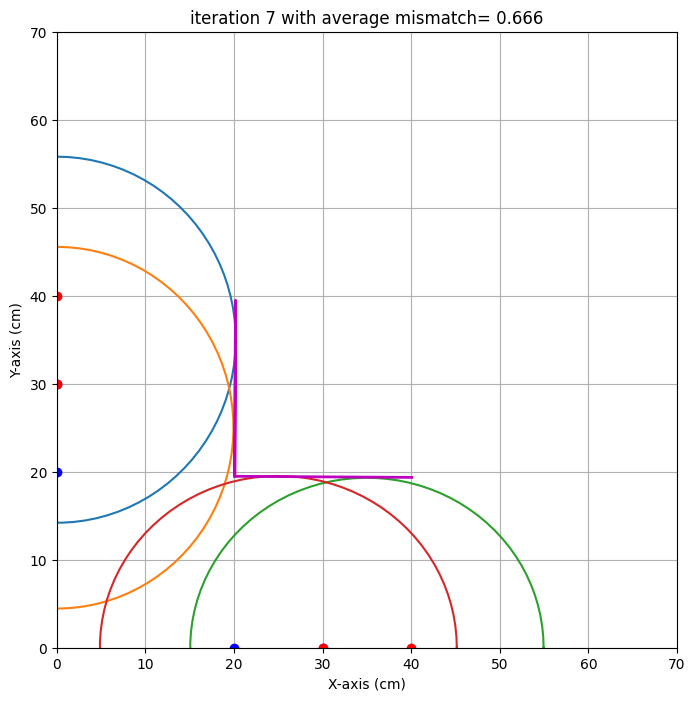

end iteration 7 with average mismatch= 0.666


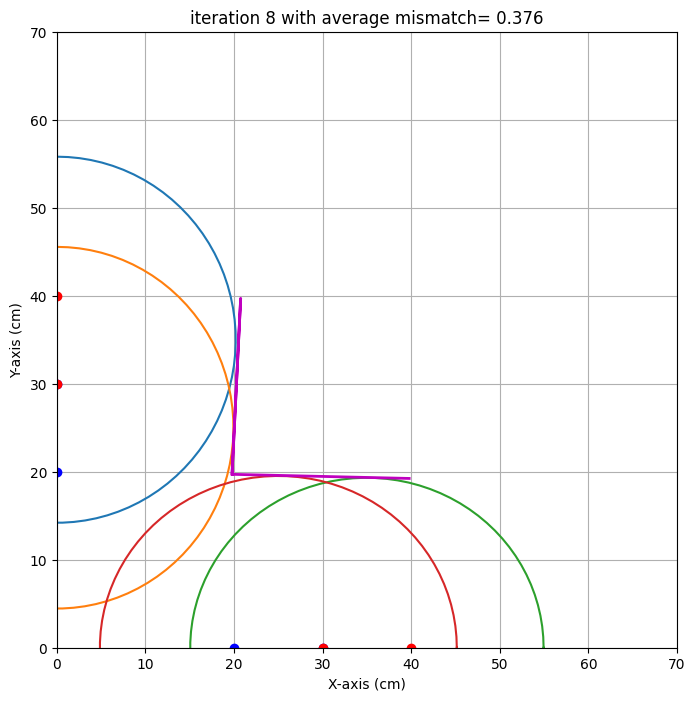

end iteration 8 with average mismatch= 0.376
end iteration 9 with average mismatch= 0.345
end iteration 10 with average mismatch= 0.339
end iteration 11 with average mismatch= 0.339
end iteration 12 with average mismatch= 0.339
end iteration 13 with average mismatch= 0.339
end iteration 14 with average mismatch= 0.339
end iteration 15 with average mismatch= 0.339
end iteration 16 with average mismatch= 0.339
end iteration 17 with average mismatch= 0.339
end iteration 18 with average mismatch= 0.339
end iteration 19 with average mismatch= 0.339
end iteration 20 with average mismatch= 0.339
end iteration 21 with average mismatch= 0.339
end iteration 22 with average mismatch= 0.339
end iteration 23 with average mismatch= 0.339
end iteration 24 with average mismatch= 0.339
end iteration 25 with average mismatch= 0.339
end iteration 26 with average mismatch= 0.339
end iteration 27 with average mismatch= 0.339
end iteration 28 with average mismatch= 0.339
end iteration 29 with average mismat

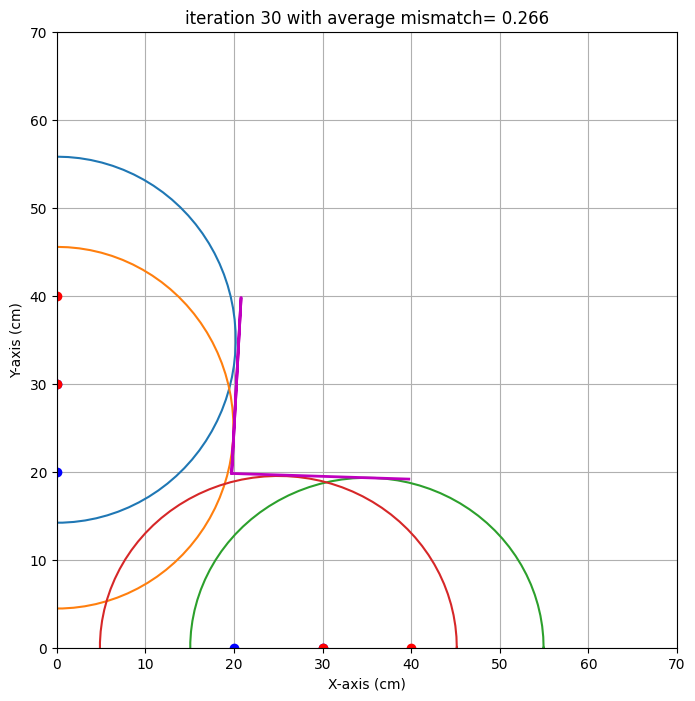

end iteration 30 with average mismatch= 0.266
###############################################################################
end of iteration  30
Best alpha=  -1.83 with uncertainty=   1.95
Best beta =   3.04 with uncertainty=   3.10
Best x0   =  19.73 with uncertainty=   0.44
Best y0   =  19.80 with uncertainty=   0.39
###############################################################################


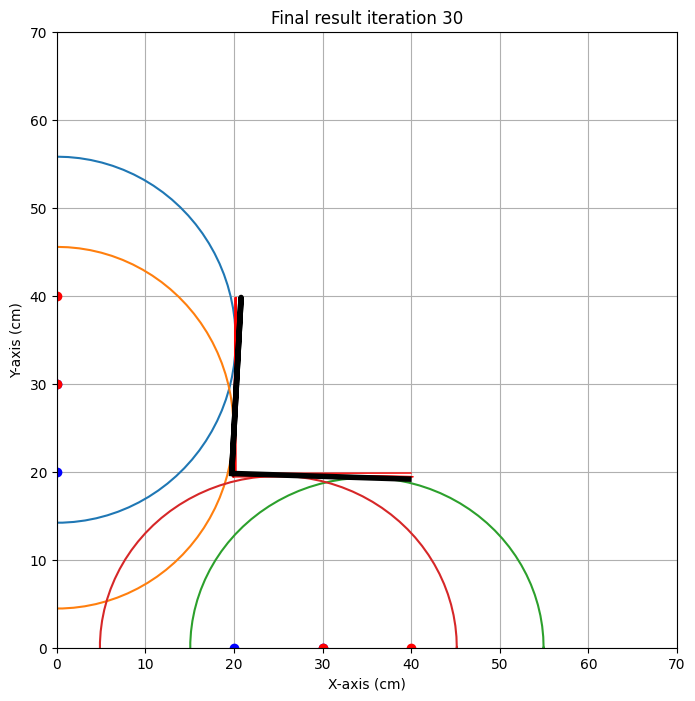

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.6],
    [0,30,0,20,41.1],
    #[0,10,0,20,180], deze meting was onrealistisch, dus uitgecomment
    [40,0,30,0,39.9],
    [30,0,20,0,40.3],
    #[10,0,20,0,199.98], deze meting ongeldig voor dezelfde reden, hij pakt de hoek
    #[10,0,0,10,187.63], deze meting ongeldig, nam de hoek mee    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.7 cm met een standaardafwijking van 0.4 cm 
y0: 19.8 cm met een standaardafwijking van 0.4 cm 
alpha: -1.8 graden met een standaardafwijking van 2.0 graad 
beta: 3.0 graden met een standaardafwijking van 3.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Kimi]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="iteratie0Kimi.jpeg" width="400">

#### algoritme [Frank]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Iteratie0Frank.jpeg" width="400">

geen derde student

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35,
           'y0':32,#zelf aanvullen,
           'alpha' :30, #zelf aanvullen,
           'beta' : 0,#zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Frank' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45,0,70,0,69.8],
    [45,0,20,0,66.8],
    #[0,45,0,70,x]
    [0,45,0,20,63.3],
    [0,60,0,20,71.6],
    [70,0,30,0,71.4]
    ]),
    'Kimi' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,40,0,x],
    [50,0,60,0,84.2],
    [0,30,0,40,71.4],
    #[0,35,0,45,x],
    #[0,40,0,50,x],
    [0,35,0,45,67.9],
    [0,40,0,50,65.5]
    ])
      }

## Opdracht 7: Evaluatie.

Frank
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  70   0  69.8
1  45   0  20   0  66.8
2   0  45   0  20  63.3
3   0  60   0  20  71.6
4  70   0  30   0  71.4


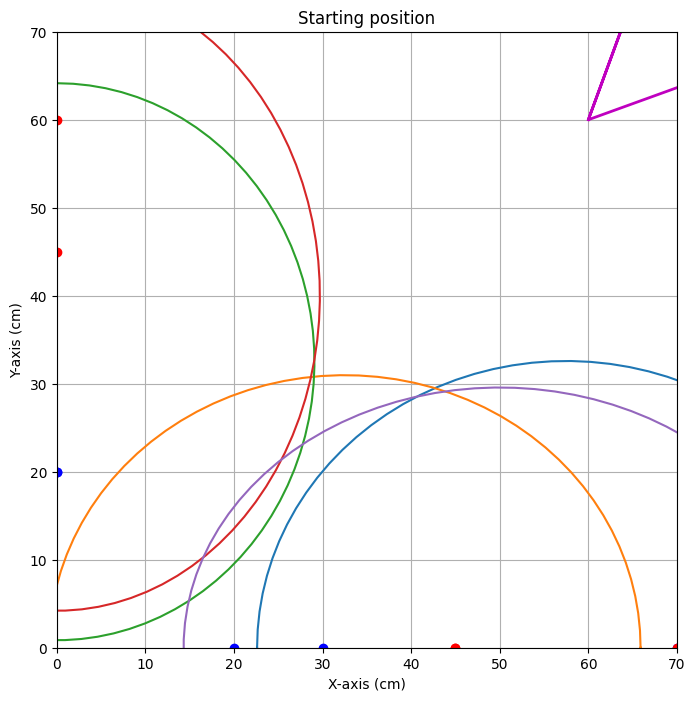


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.630


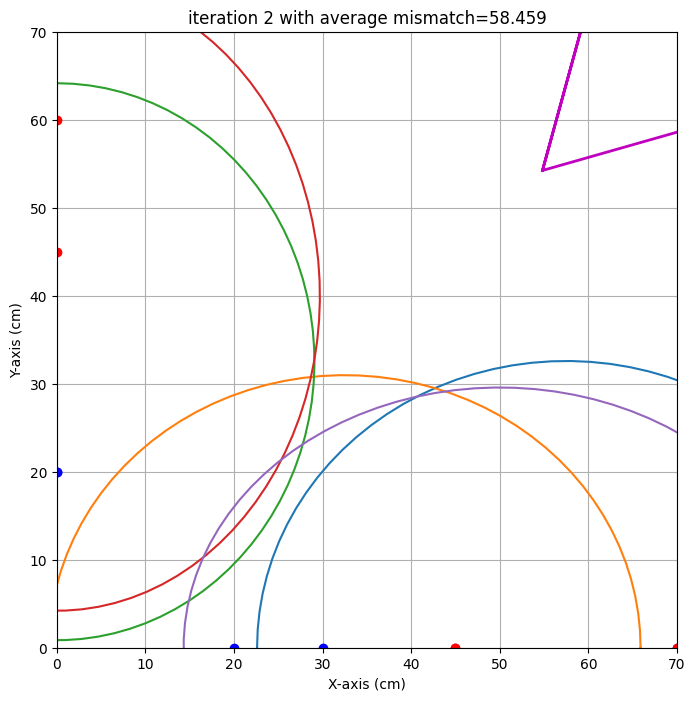

end iteration 2 with average mismatch=58.459


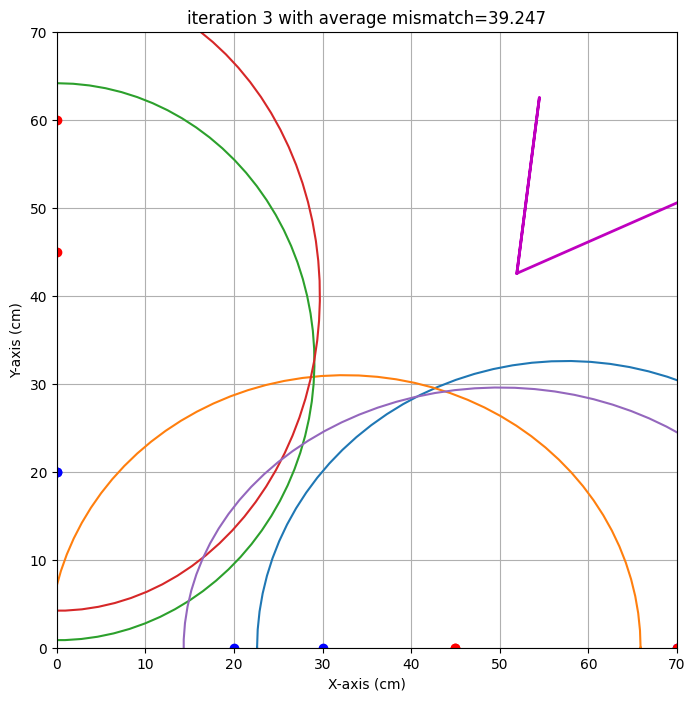

end iteration 3 with average mismatch=39.247


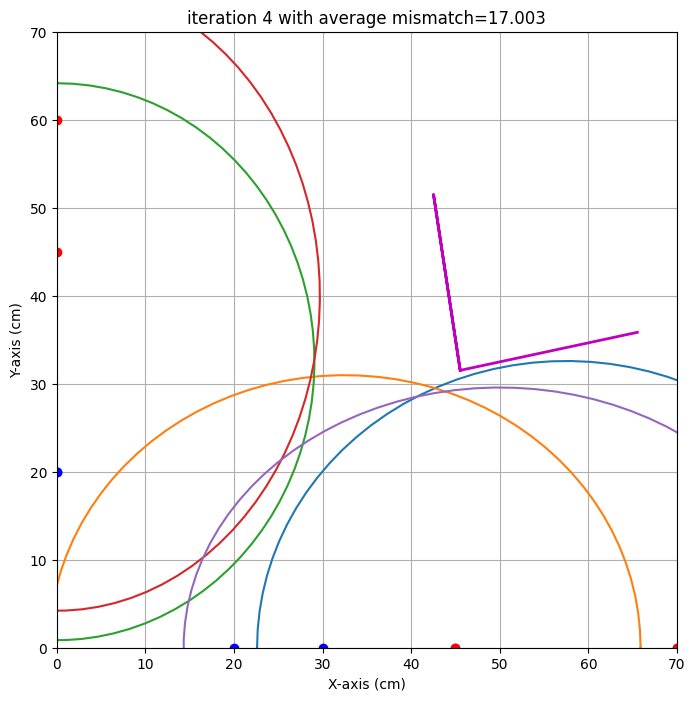

end iteration 4 with average mismatch=17.003


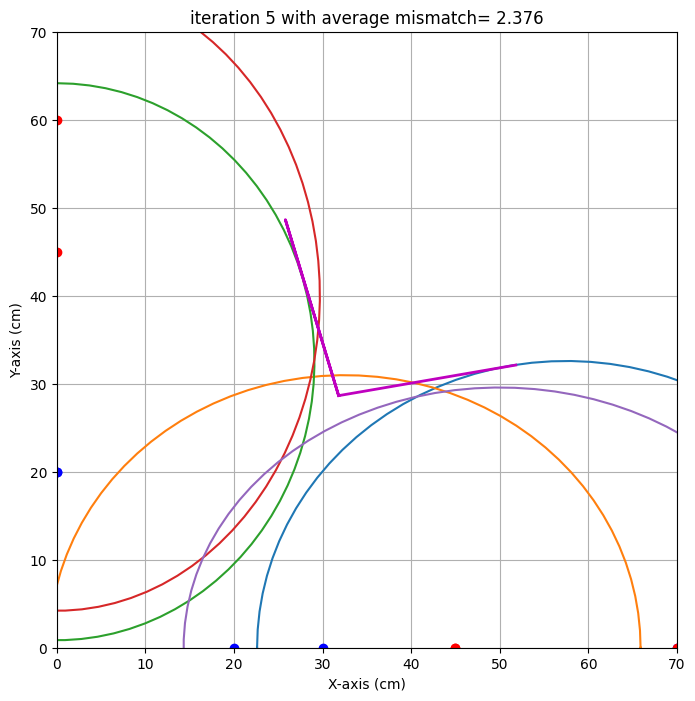

end iteration 5 with average mismatch= 2.376
end iteration 6 with average mismatch= 2.347
end iteration 7 with average mismatch= 2.275
end iteration 8 with average mismatch= 2.274
end iteration 9 with average mismatch= 2.274
end iteration 10 with average mismatch= 2.269
end iteration 11 with average mismatch= 2.269
end iteration 12 with average mismatch= 2.269
end iteration 13 with average mismatch= 2.269
end iteration 14 with average mismatch= 2.263
end iteration 15 with average mismatch= 2.263
end iteration 16 with average mismatch= 2.254
end iteration 17 with average mismatch= 2.254
end iteration 18 with average mismatch= 2.254
end iteration 19 with average mismatch= 2.254
end iteration 20 with average mismatch= 2.254
end iteration 21 with average mismatch= 2.232
end iteration 22 with average mismatch= 2.192
end iteration 23 with average mismatch= 2.140
end iteration 24 with average mismatch= 2.140
end iteration 25 with average mismatch= 2.140
end iteration 26 with average mismatch=

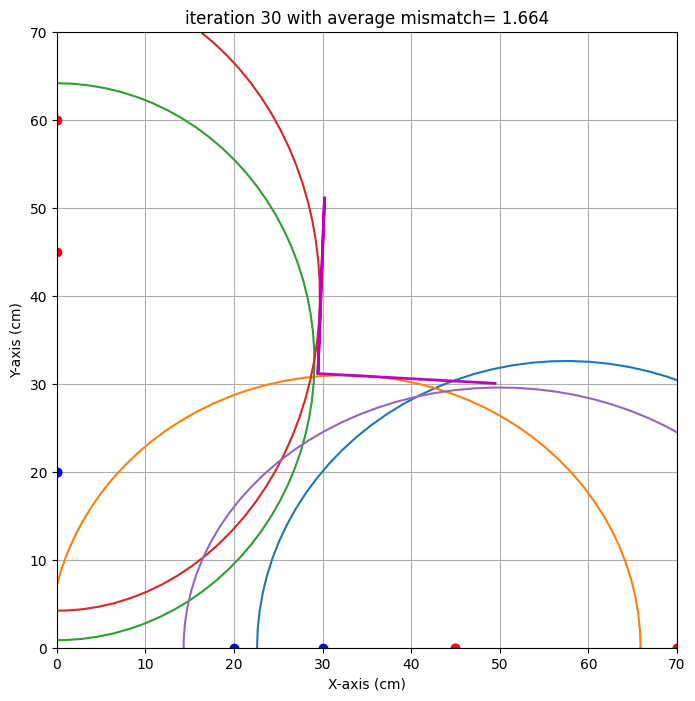

end iteration 30 with average mismatch= 1.664
###############################################################################
end of iteration  30
Best alpha=  -3.17 with uncertainty=  13.23
Best beta =   2.14 with uncertainty=  14.80
Best x0   =  29.47 with uncertainty=   1.83
Best y0   =  31.15 with uncertainty=   3.13
###############################################################################


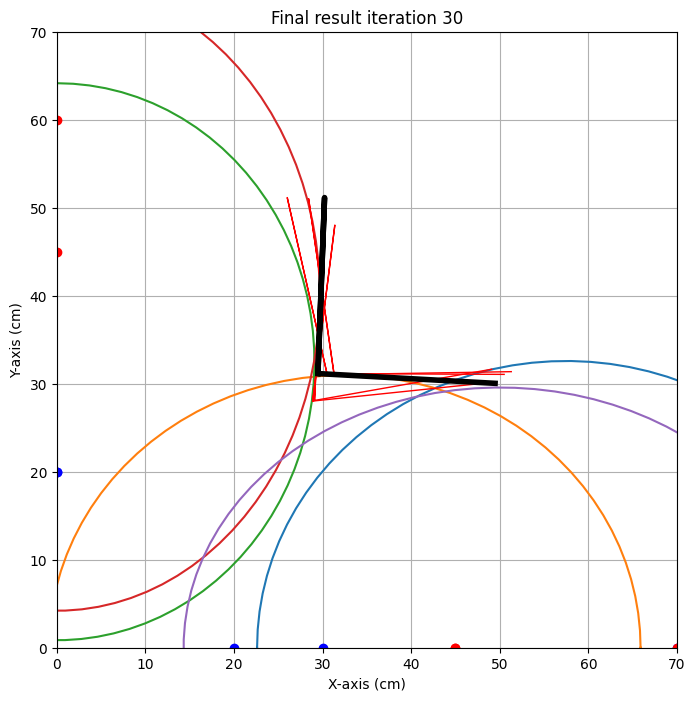

{'alpha': np.float64(-3.174375459331335), 'alpha_eps': np.float64(13.23198068849803), 'beta': np.float64(2.140297556101393), 'beta_eps': np.float64(14.796801475513082), 'x0': np.float64(29.470916914511715), 'x0_eps': np.float64(1.8283229160499275), 'y0': np.float64(31.154201309018127), 'y0_eps': np.float64(3.1251319629724534)}
Kimi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  50   0  60   0  84.2
1   0  30   0  40  71.4
2   0  35   0  45  67.9
3   0  40   0  50  65.5


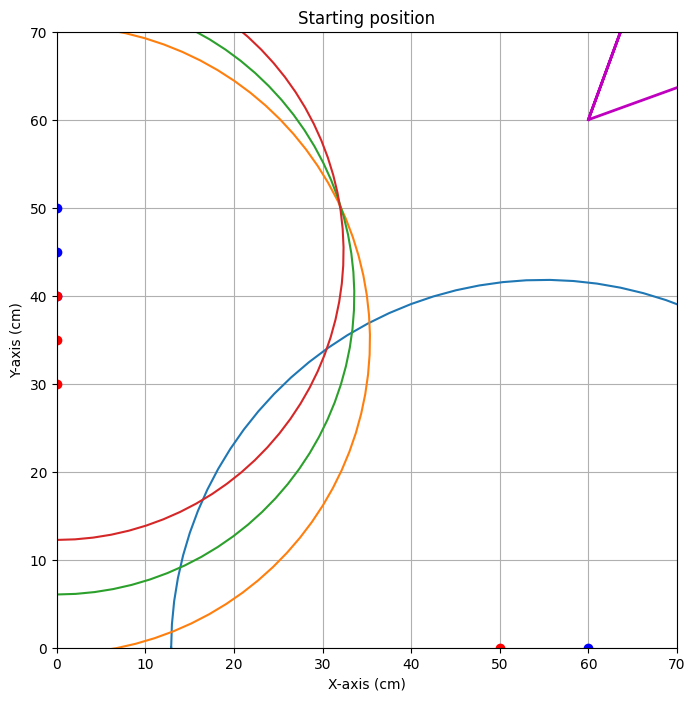


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=58.813


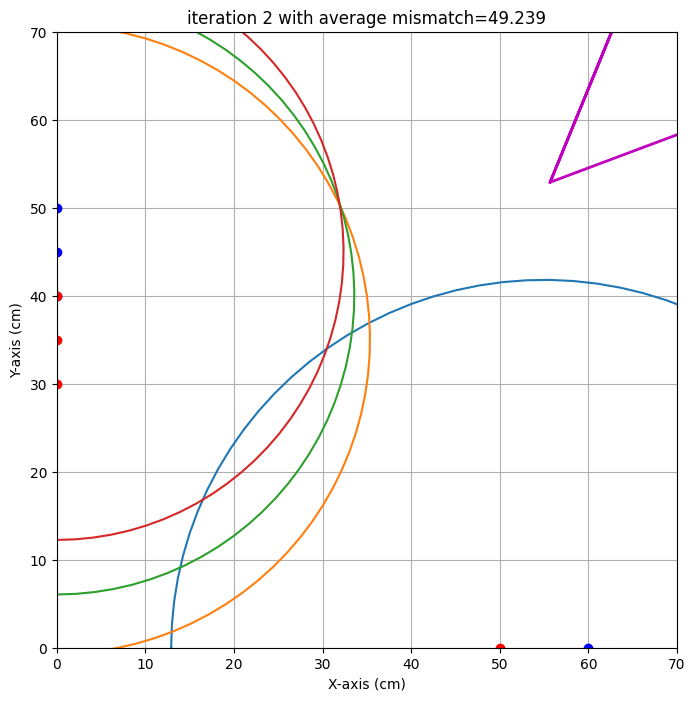

end iteration 2 with average mismatch=49.239


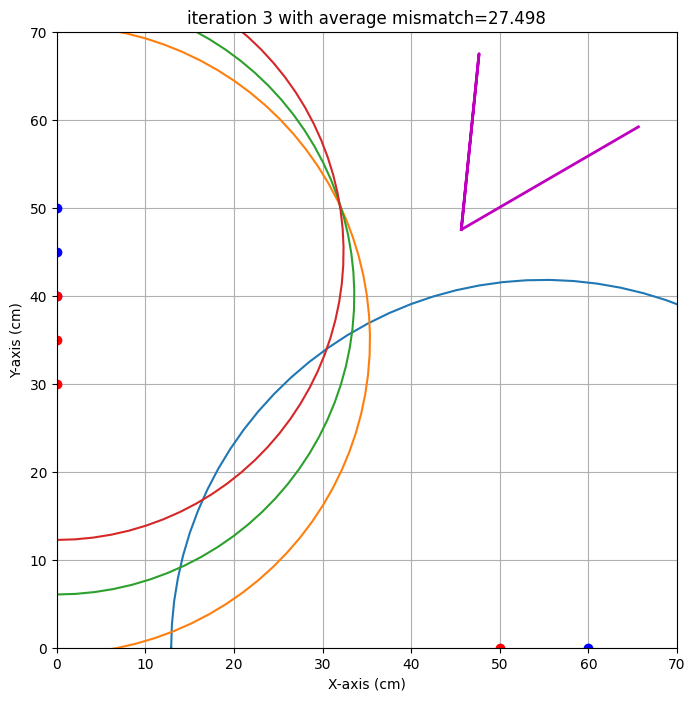

end iteration 3 with average mismatch=27.498


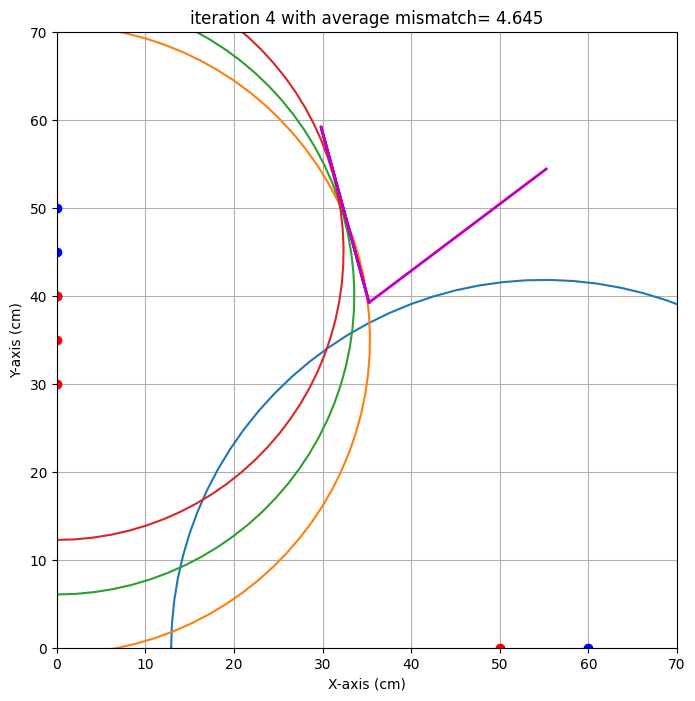

end iteration 4 with average mismatch= 4.645


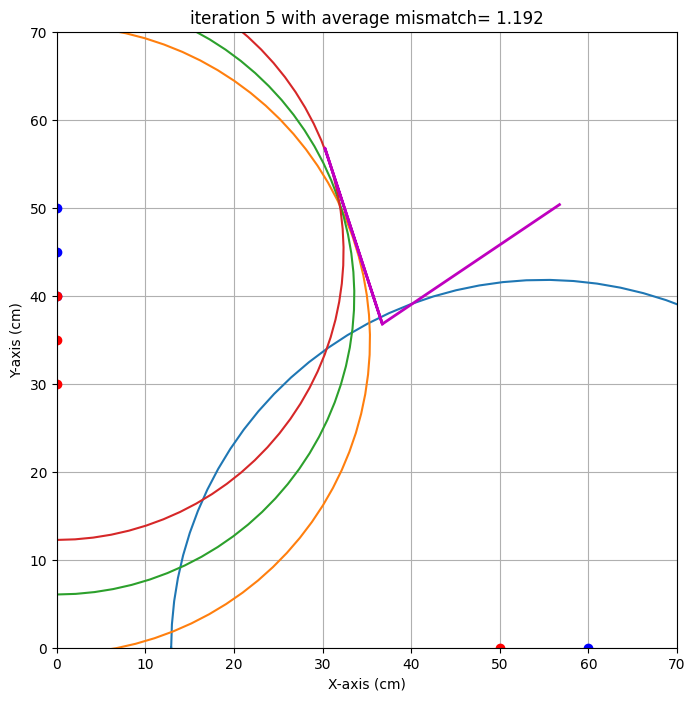

end iteration 5 with average mismatch= 1.192
end iteration 6 with average mismatch= 1.124


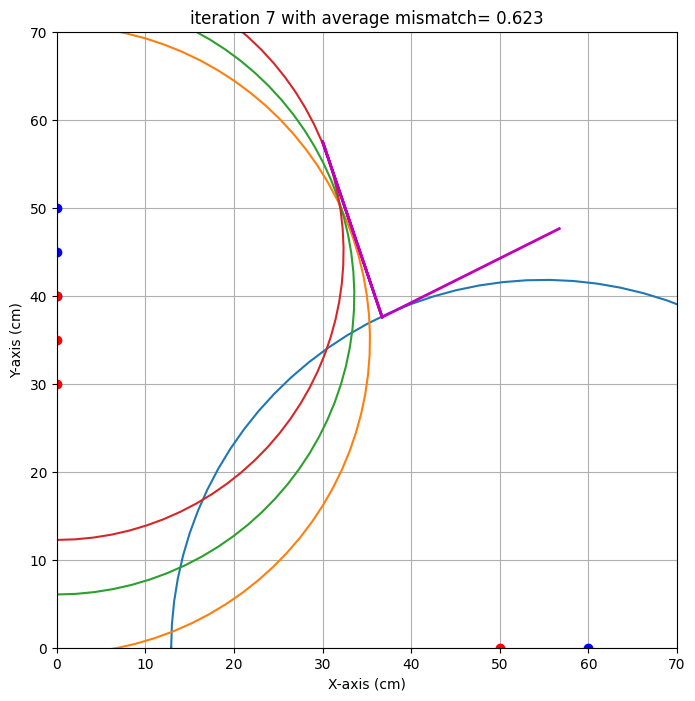

end iteration 7 with average mismatch= 0.623
end iteration 8 with average mismatch= 0.602


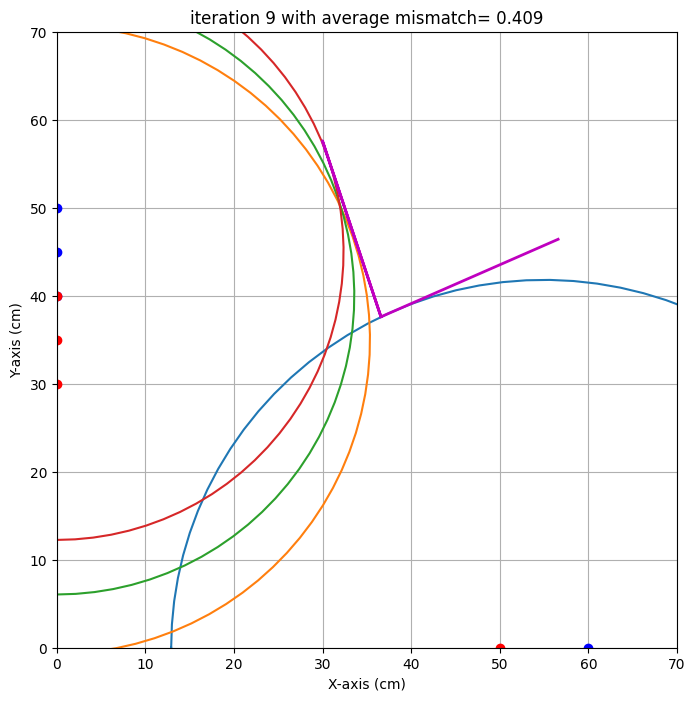

end iteration 9 with average mismatch= 0.409
end iteration 10 with average mismatch= 0.388
end iteration 11 with average mismatch= 0.381
end iteration 12 with average mismatch= 0.380
end iteration 13 with average mismatch= 0.380
end iteration 14 with average mismatch= 0.380
end iteration 15 with average mismatch= 0.380
end iteration 16 with average mismatch= 0.379
end iteration 17 with average mismatch= 0.344
end iteration 18 with average mismatch= 0.327
end iteration 19 with average mismatch= 0.323
end iteration 20 with average mismatch= 0.323
end iteration 21 with average mismatch= 0.323
end iteration 22 with average mismatch= 0.323
end iteration 23 with average mismatch= 0.322
end iteration 24 with average mismatch= 0.293
end iteration 25 with average mismatch= 0.291
end iteration 26 with average mismatch= 0.290
end iteration 27 with average mismatch= 0.290
end iteration 28 with average mismatch= 0.290
end iteration 29 with average mismatch= 0.290
Last iteration, also determine unce

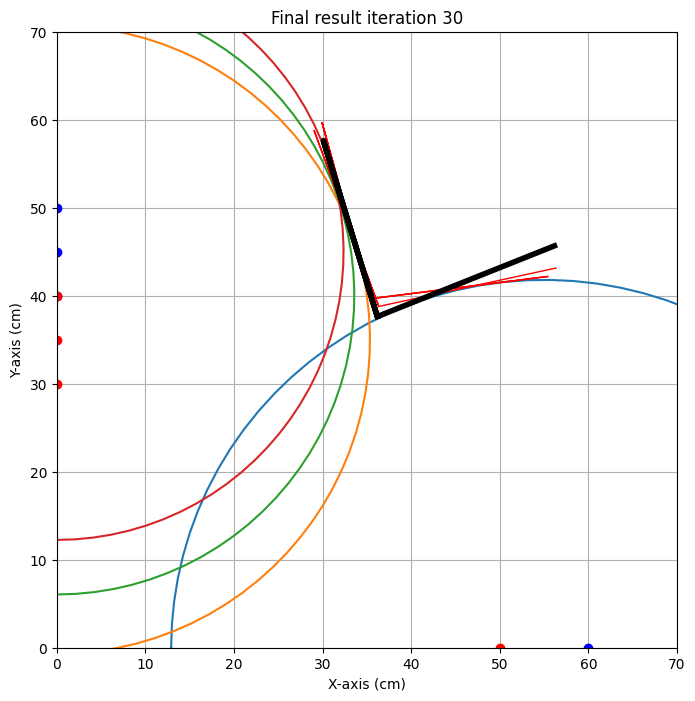

{'alpha': np.float64(21.885398931473702), 'alpha_eps': np.float64(14.690236327099715), 'beta': np.float64(-16.931716159390824), 'beta_eps': np.float64(3.131258667963195), 'x0': np.float64(36.17313301455263), 'x0_eps': np.float64(0.7778403615483782), 'y0': np.float64(37.634579767800055), 'y0_eps': np.float64(2.0233198942935005)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Frank 
x0 target is : 35.0. Gevonden waarde: 29.5 cm met een standaardafwijking van 1.8 cm 
y0 target is : 32.0. Gevonden waarde: 31.2 cm met een standaardafwijking van 3.1 cm 
alpha target is : 30.0. Gevonden waarde: -3.2 graden met een standaardafwijking van 13.2 graad 
beta target is : 0.0. Gevonden waarde: 2.1 graden met een standaardafwijking van 14.8 graad 

Kimi 
x0 target is : 35.0. Gevonden waarde: 36.2 cm met een standaardafwijking van 0.8 cm 
y0 target is : 32.0. Gevonden waarde: 37.6 cm met een standaardafwijking van 2.0 cm 
alpha target is : 30.0. Gevonden waarde: 21.9 graden met een standaardafwijking van 14.7 graad 
beta target is : 0.0. Gevonden waarde: -16.9 graden met een standaardafwijking van 3.1 graad 



## Opdracht 8: Iteratie1+.14:20.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie1.jpeg)


## Iteratie 15:02.

Nu naar iteratie 2

Figuur: ![Alt](iteratie2.jpeg)

In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  61.0
1  70   0  30   0  70.2
2   0  45   0  20  56.9
3   0  45   0  70  65.9
4  20   0  70   0  77.1
5   0  70   0  20  73.3


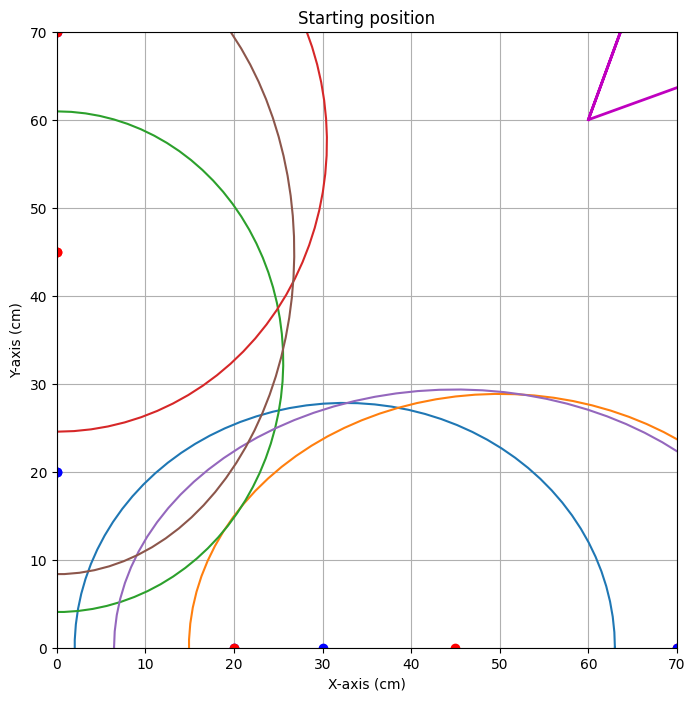


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.422


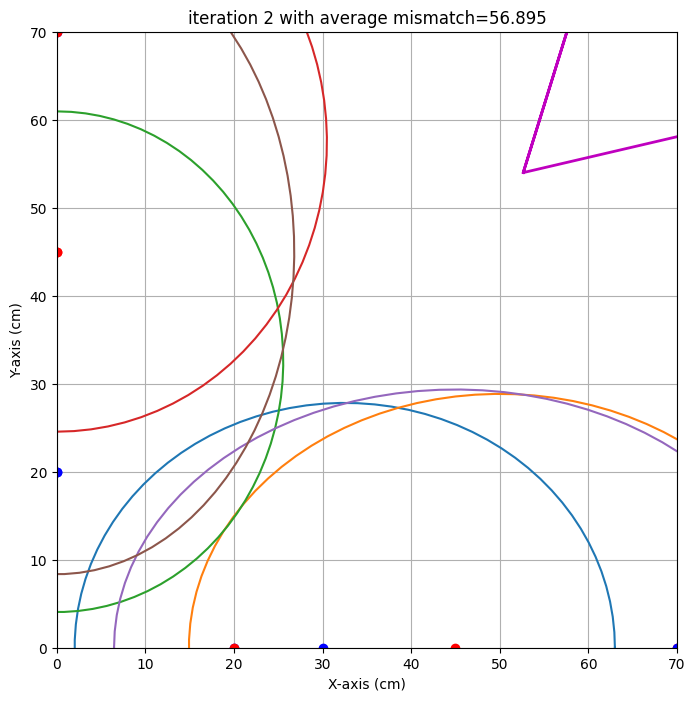

end iteration 2 with average mismatch=56.895


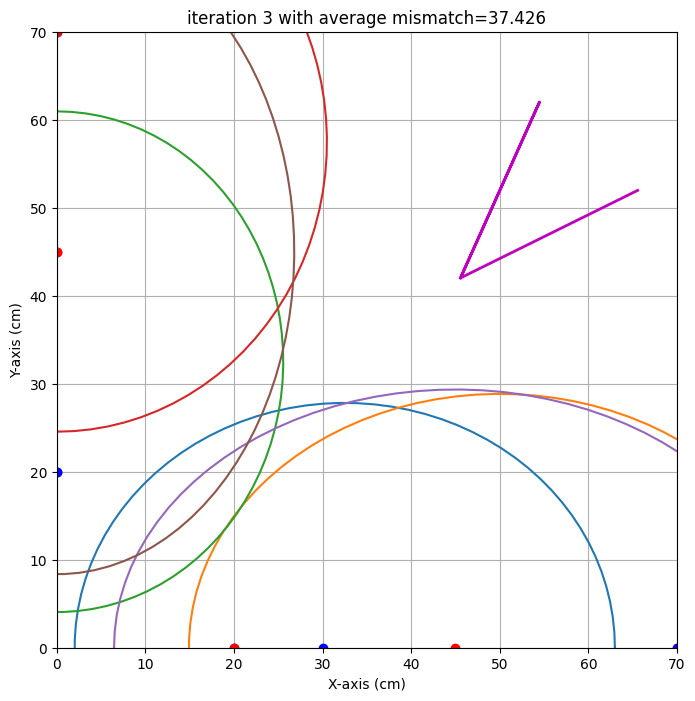

end iteration 3 with average mismatch=37.426


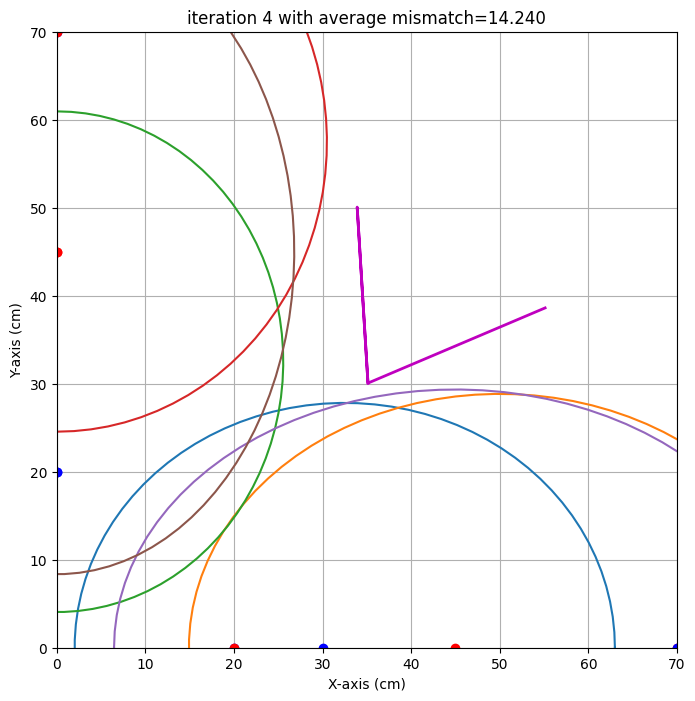

end iteration 4 with average mismatch=14.240


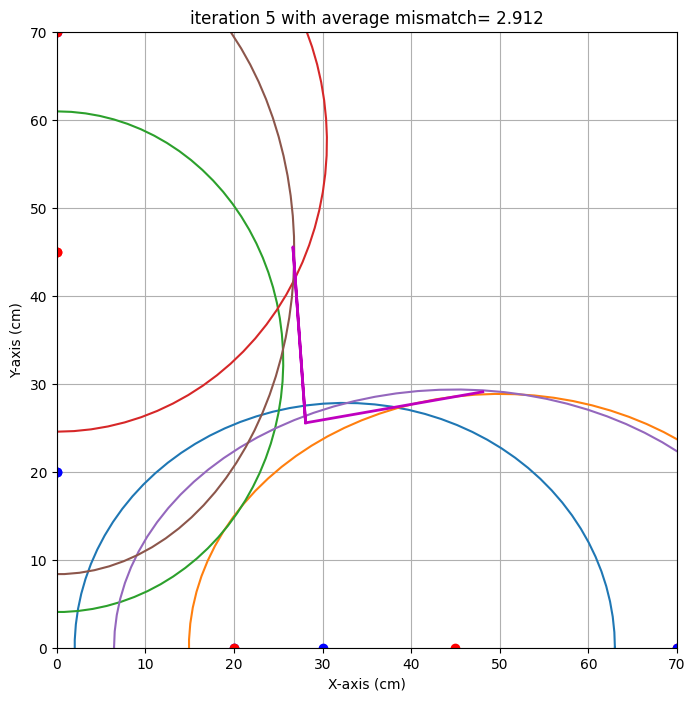

end iteration 5 with average mismatch= 2.912


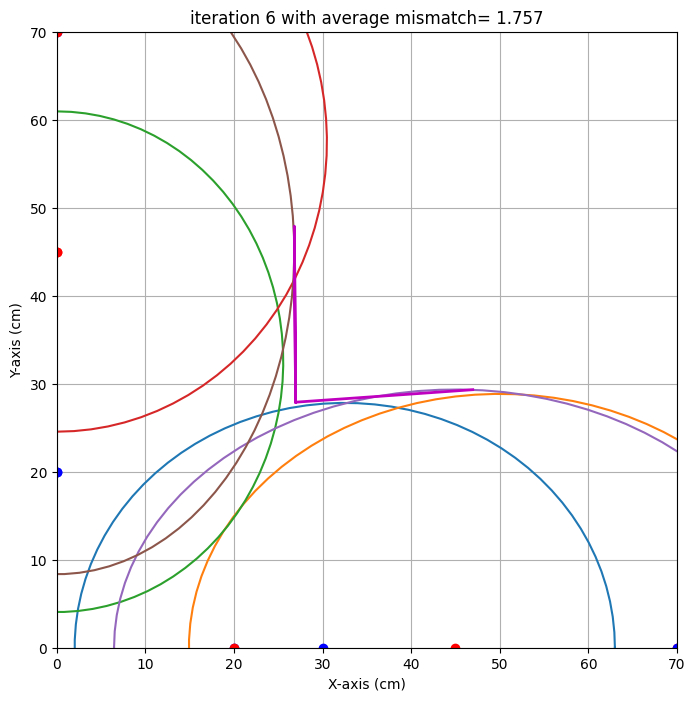

end iteration 6 with average mismatch= 1.757
end iteration 7 with average mismatch= 1.716


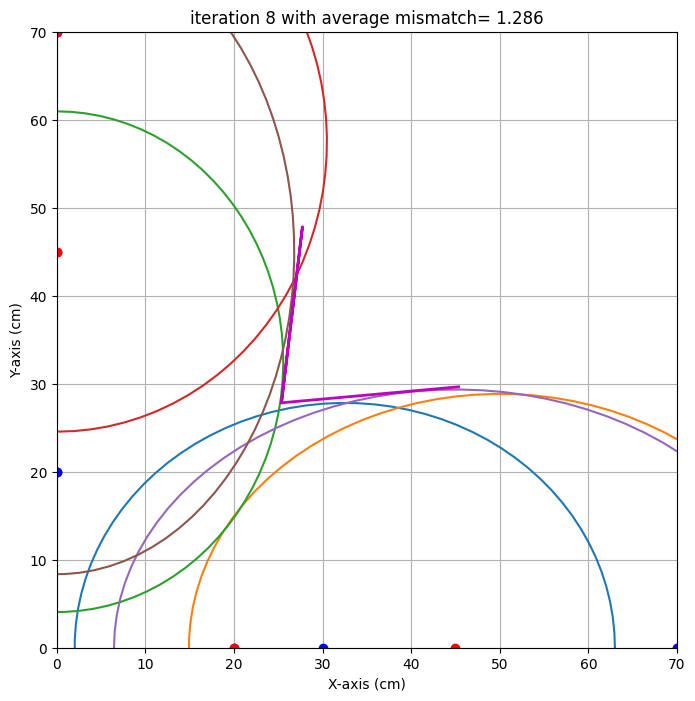

end iteration 8 with average mismatch= 1.286


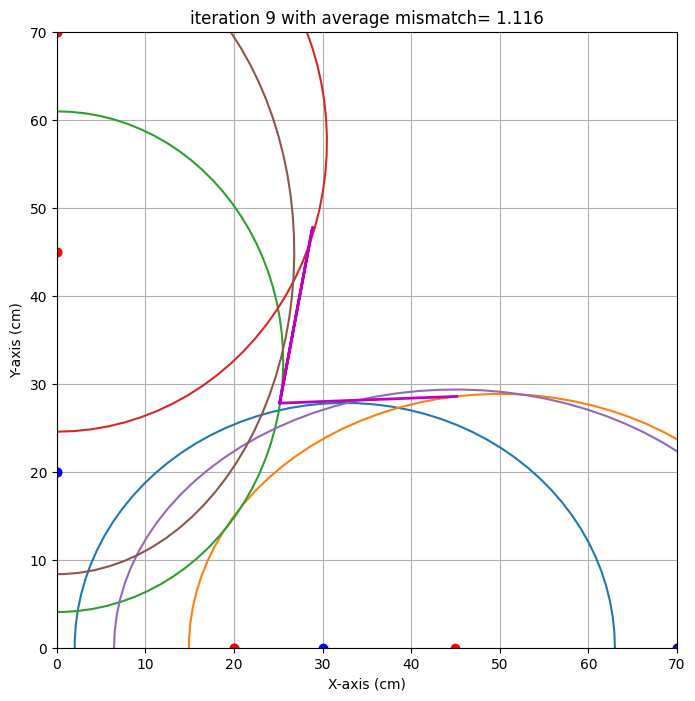

end iteration 9 with average mismatch= 1.116
end iteration 10 with average mismatch= 1.116
end iteration 11 with average mismatch= 1.116
end iteration 12 with average mismatch= 1.113
end iteration 13 with average mismatch= 1.052
end iteration 14 with average mismatch= 1.052
end iteration 15 with average mismatch= 1.052
end iteration 16 with average mismatch= 1.052
end iteration 17 with average mismatch= 1.052
end iteration 18 with average mismatch= 1.052
end iteration 19 with average mismatch= 1.051
end iteration 20 with average mismatch= 1.019
end iteration 21 with average mismatch= 1.019
end iteration 22 with average mismatch= 1.016
end iteration 23 with average mismatch= 1.016
end iteration 24 with average mismatch= 1.016
end iteration 25 with average mismatch= 1.016
end iteration 26 with average mismatch= 1.016
end iteration 27 with average mismatch= 1.016
end iteration 28 with average mismatch= 1.016
end iteration 29 with average mismatch= 1.016
Last iteration, also determine unce

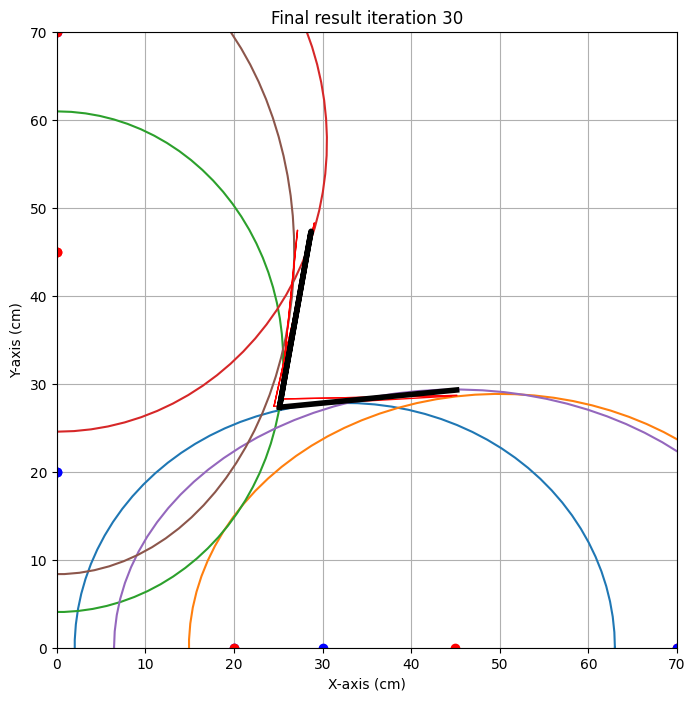

{'alpha': np.float64(5.6141569519812204), 'alpha_eps': np.float64(4.452318514352616), 'beta': np.float64(10.125480328438861), 'beta_eps': np.float64(4.370846889260274), 'x0': np.float64(25.12688414404002), 'x0_eps': np.float64(0.6157249233265638), 'y0': np.float64(27.32358847309747), 'y0_eps': np.float64(0.9380057501104808)}
locatie 1 
x0 target is : 22.0. Gevonden waarde: 25.1 cm met een standaardafwijking van 0.6 cm 
y0 target is : 26.0. Gevonden waarde: 27.3 cm met een standaardafwijking van 0.9 cm 
alpha target is : 10.0. Gevonden waarde: 5.6 graden met een standaardafwijking van 4.5 graad 
beta target is : 20.0. Gevonden waarde: 10.1 graden met een standaardafwijking van 4.4 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie 1

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':22,
                    'y0':26,
                    'alpha' : 10,
                    'beta' : 20,
        #    'locatie 2':{'x0':#zelf aanvullen,
        #             'y0':#zelf aanvullen,
        #             'alpha' : #zelf aanvullen,
        #             'beta' : #zelf aanvullen}
             }}
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [45, 0, 20, 0, 61.0],
    [70, 0, 30, 0, 70.2],
    [0, 45, 0, 20, 56.9],
    [0, 45, 0, 70, 65.9],
    [20, 0, 70, 0, 77.1],
    [0, 70, 0, 20, 73.3],
    ])
    #    'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    # # zelf aanvullen
    # ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  50   0  71.6
1  45   0  70   0  78.3
2   0  45   0  20  89.0
3   0  45   0  70  85.4
4  20   0  70   0  88.4
5   0  70   0  20  93.6
6   0  25   0  45  86.4
7   0  50   0  65  83.5
8  50   0  65   0  76.0


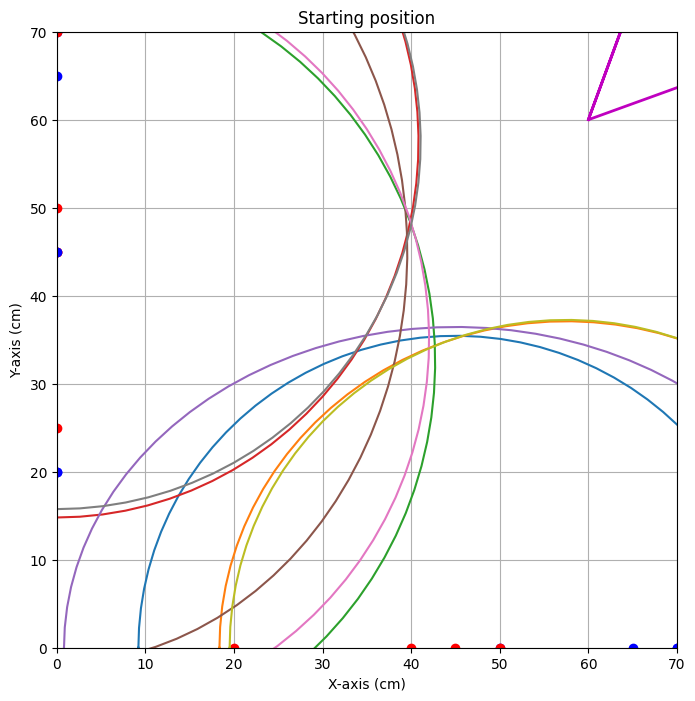


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=49.270


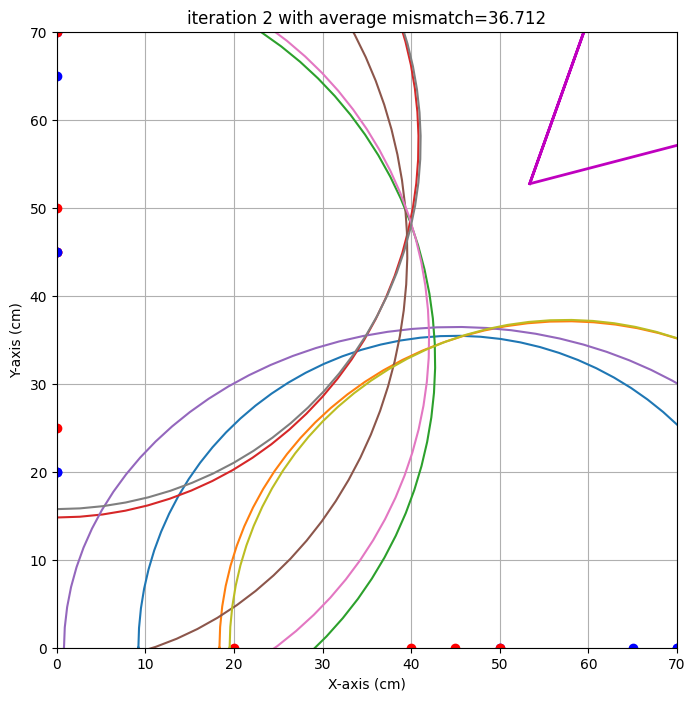

end iteration 2 with average mismatch=36.712


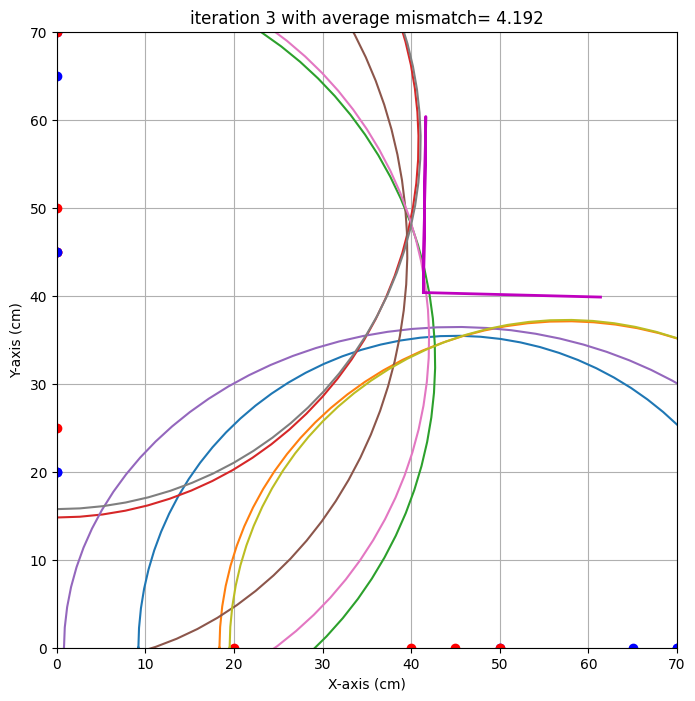

end iteration 3 with average mismatch= 4.192


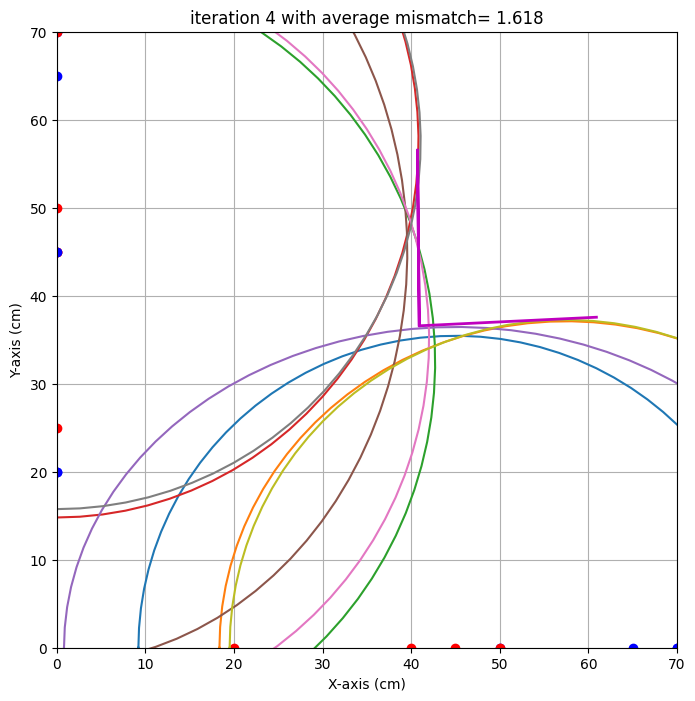

end iteration 4 with average mismatch= 1.618
end iteration 5 with average mismatch= 1.606
end iteration 6 with average mismatch= 1.584
end iteration 7 with average mismatch= 1.517
end iteration 8 with average mismatch= 1.499
end iteration 9 with average mismatch= 1.414
end iteration 10 with average mismatch= 1.411
end iteration 11 with average mismatch= 1.411
end iteration 12 with average mismatch= 1.411
end iteration 13 with average mismatch= 1.411
end iteration 14 with average mismatch= 1.411
end iteration 15 with average mismatch= 1.411
end iteration 16 with average mismatch= 1.411
end iteration 17 with average mismatch= 1.411
end iteration 18 with average mismatch= 1.411
end iteration 19 with average mismatch= 1.411
end iteration 20 with average mismatch= 1.411
end iteration 21 with average mismatch= 1.411
end iteration 22 with average mismatch= 1.411
end iteration 23 with average mismatch= 1.407
end iteration 24 with average mismatch= 1.401
end iteration 25 with average mismatch= 

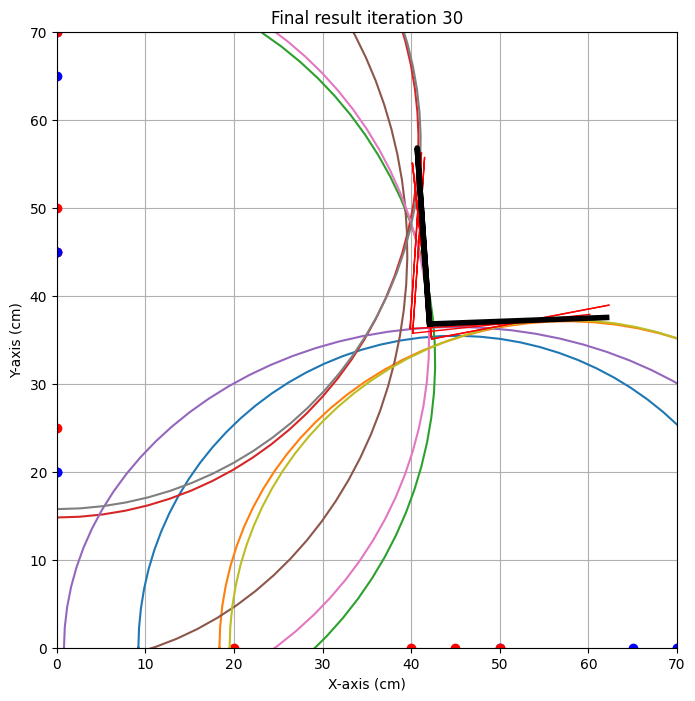

{'alpha': np.float64(2.1230713262695136), 'alpha_eps': np.float64(8.757661950859347), 'beta': np.float64(-3.9716847735148377), 'beta_eps': np.float64(7.813672027449097), 'x0': np.float64(42.066765351688325), 'x0_eps': np.float64(2.1908651038913334), 'y0': np.float64(36.78660563693663), 'y0_eps': np.float64(1.7030778225468026)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.1
1  45   0  70   0  86.8
2   0  40   0  60  88.5
3   0  45   0  70  92.5
4   0  50   0  65  89.0
5  50   0  65   0  84.5


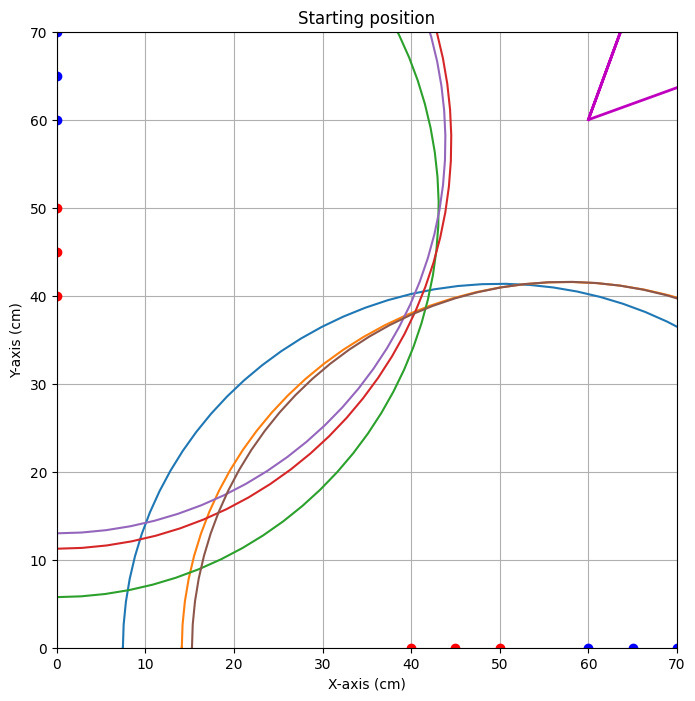


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=40.258


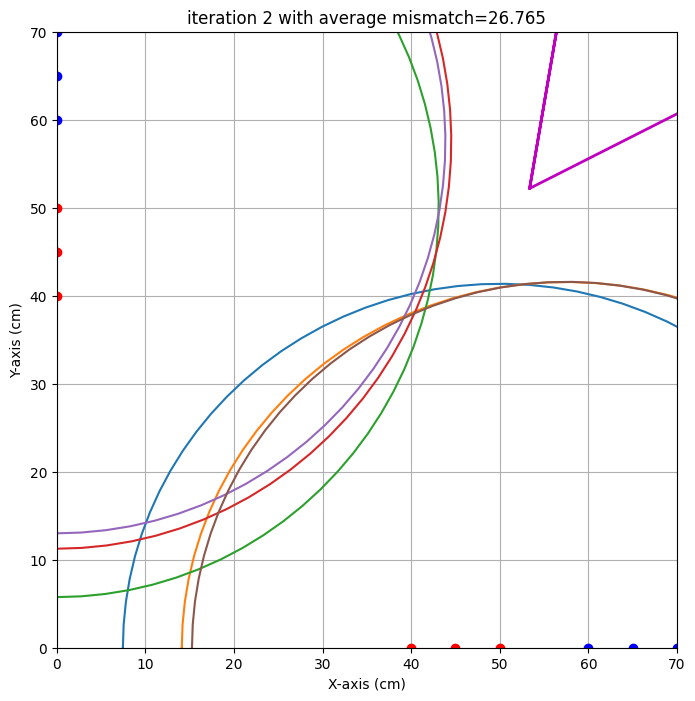

end iteration 2 with average mismatch=26.765


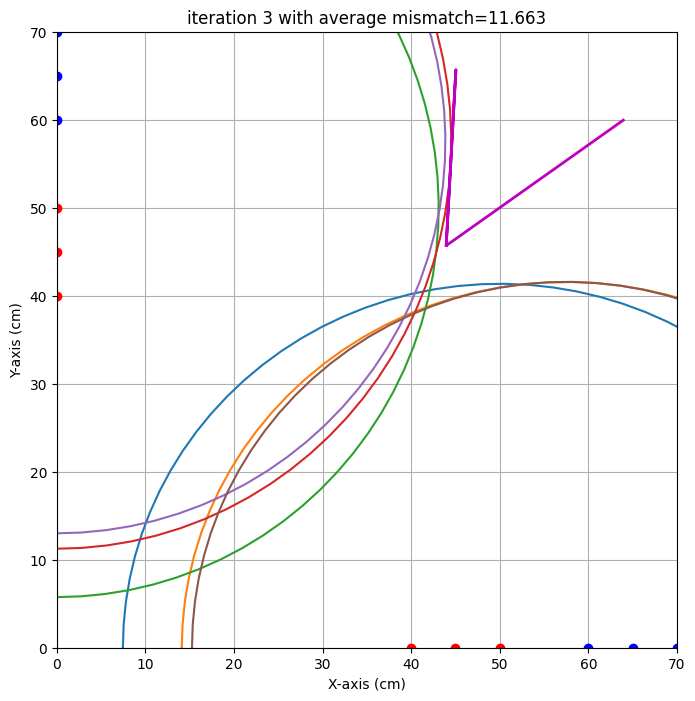

end iteration 3 with average mismatch=11.663


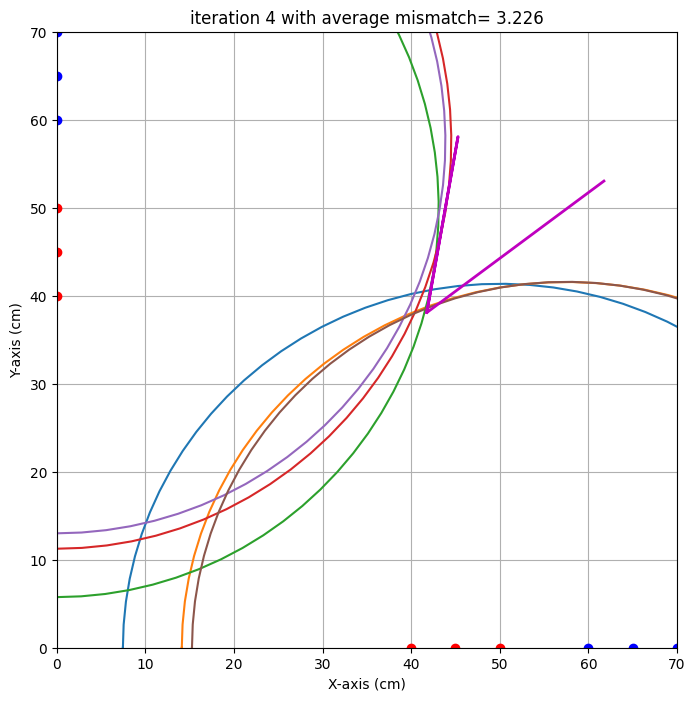

end iteration 4 with average mismatch= 3.226


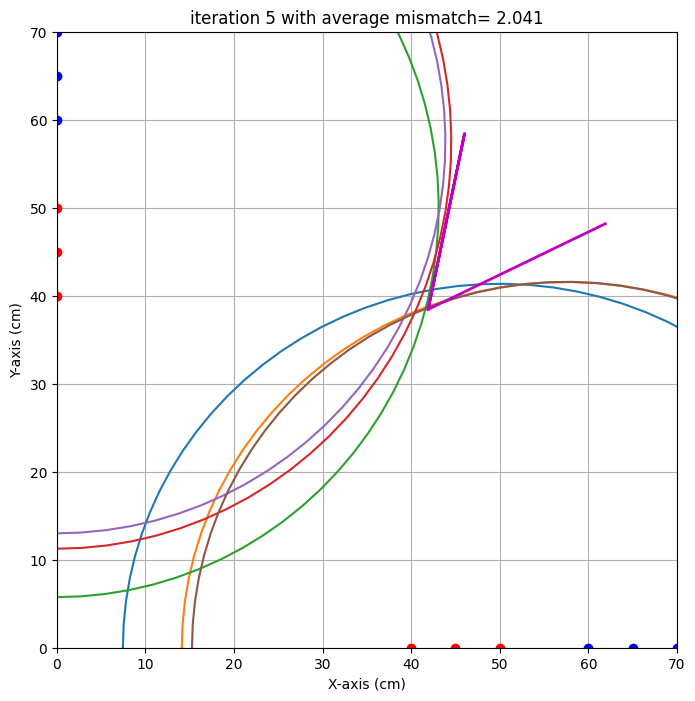

end iteration 5 with average mismatch= 2.041


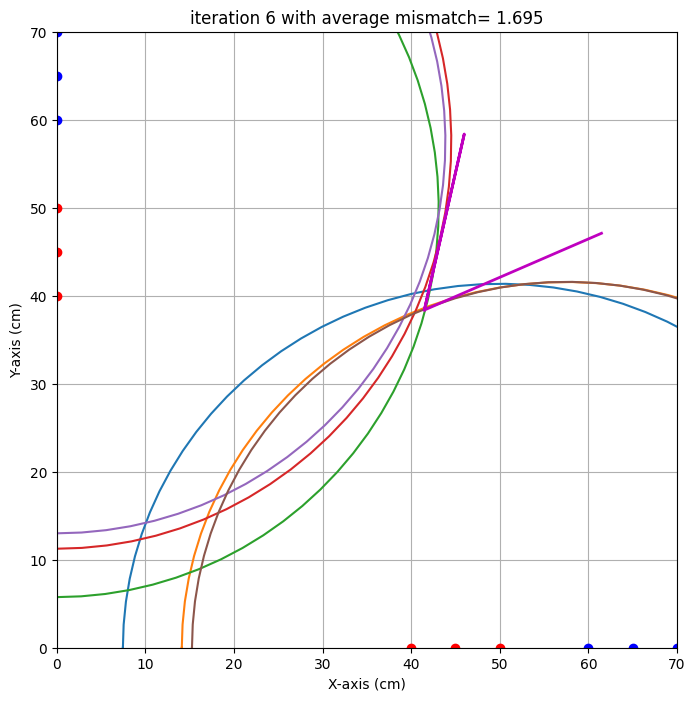

end iteration 6 with average mismatch= 1.695


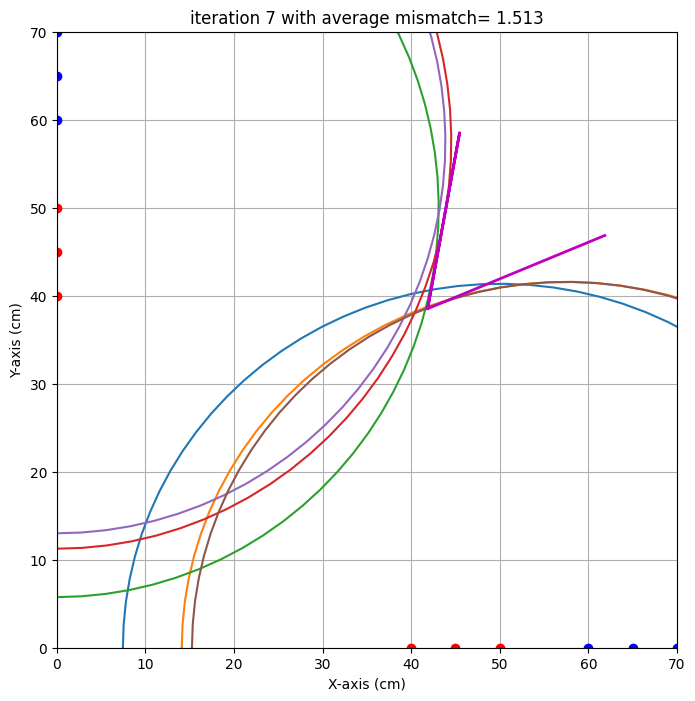

end iteration 7 with average mismatch= 1.513
end iteration 8 with average mismatch= 1.507


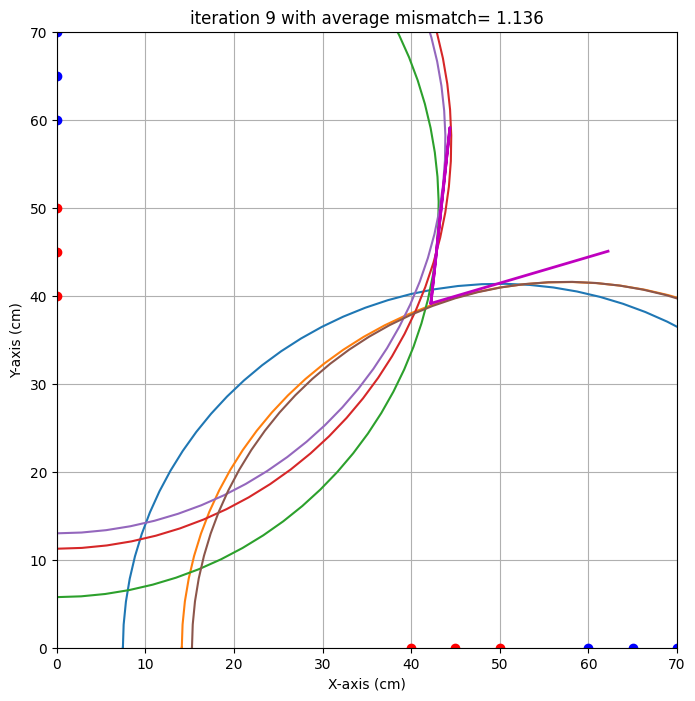

end iteration 9 with average mismatch= 1.136


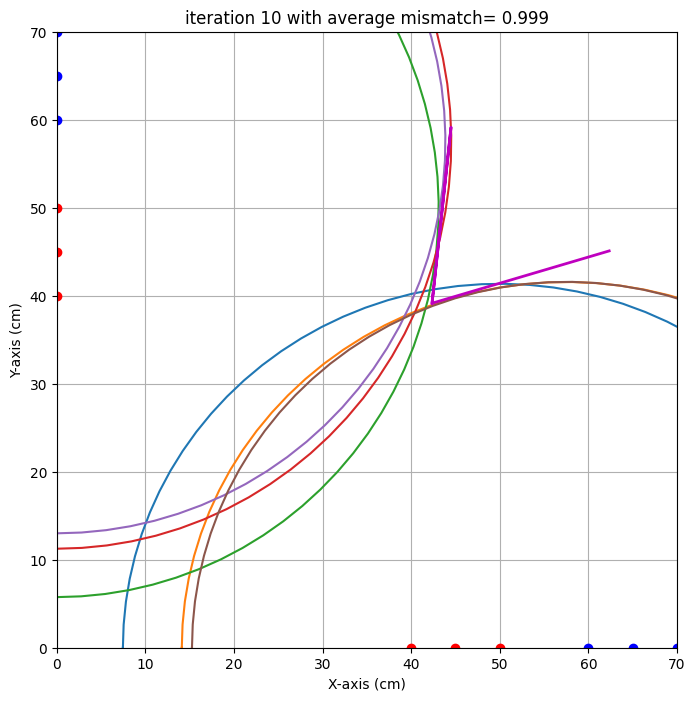

end iteration 10 with average mismatch= 0.999
end iteration 11 with average mismatch= 0.993
end iteration 12 with average mismatch= 0.992
end iteration 13 with average mismatch= 0.979
end iteration 14 with average mismatch= 0.977
end iteration 15 with average mismatch= 0.977
end iteration 16 with average mismatch= 0.928
end iteration 17 with average mismatch= 0.907
end iteration 18 with average mismatch= 0.907
end iteration 19 with average mismatch= 0.907
end iteration 20 with average mismatch= 0.880
end iteration 21 with average mismatch= 0.871


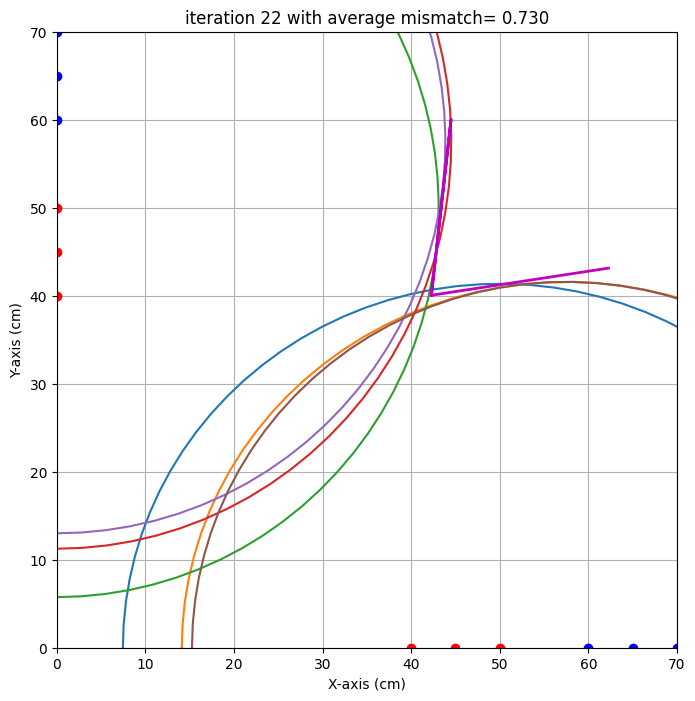

end iteration 22 with average mismatch= 0.730


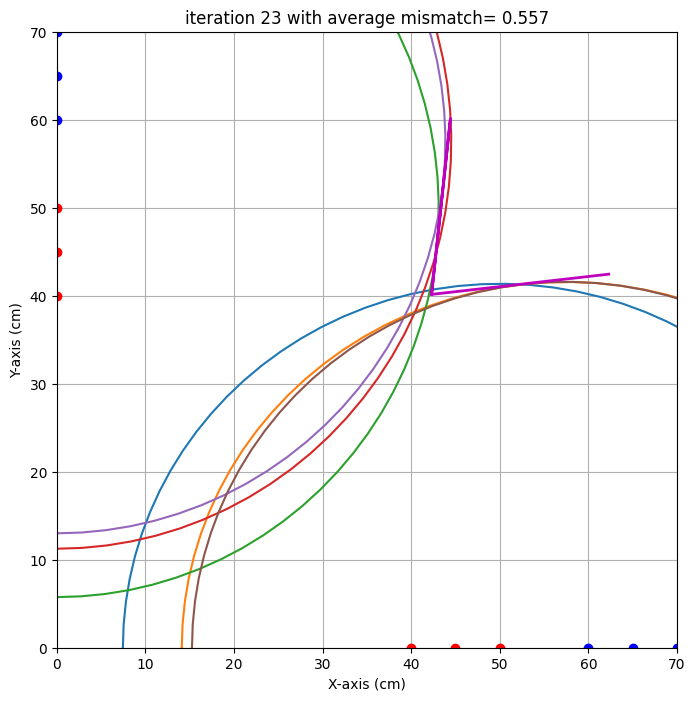

end iteration 23 with average mismatch= 0.557
end iteration 24 with average mismatch= 0.556
end iteration 25 with average mismatch= 0.556


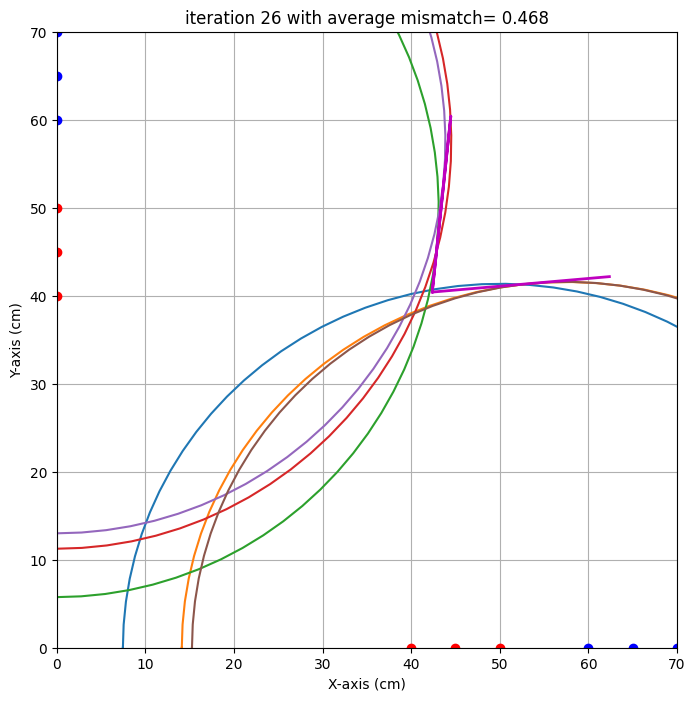

end iteration 26 with average mismatch= 0.468
end iteration 27 with average mismatch= 0.454
end iteration 28 with average mismatch= 0.450
end iteration 29 with average mismatch= 0.450
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.450
###############################################################################
end of iteration  30
Best alpha=   5.01 with uncertainty=  10.58
Best beta =   5.97 with uncertainty=   6.04
Best x0   =  42.35 with uncertainty=   0.85
Best y0   =  40.41 with uncertainty=   2.86
###############################################################################


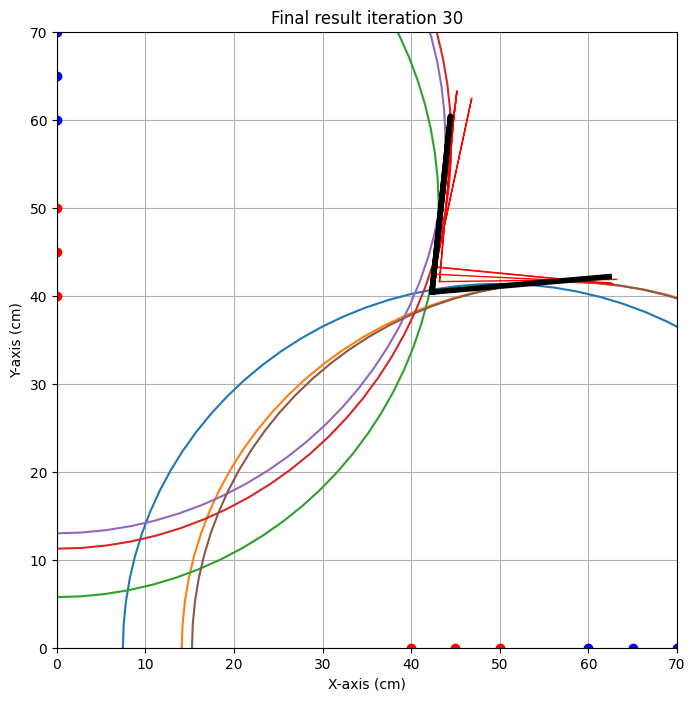

{'alpha': np.float64(5.012769804235972), 'alpha_eps': np.float64(10.57659510317938), 'beta': np.float64(5.9707430532088885), 'beta_eps': np.float64(6.044993757046182), 'x0': np.float64(42.34753133305432), 'x0_eps': np.float64(0.8461932737967288), 'y0': np.float64(40.41080260035386), 'y0_eps': np.float64(2.856021029220365)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 42.1 cm met een standaardafwijking van 2.2 cm 
y0 target is : 32.0. Gevonden waarde: 36.8 cm met een standaardafwijking van 1.7 cm 
alpha target is : 10.0. Gevonden waarde: 2.1 graden met een standaardafwijking van 8.8 graad 
beta target is : 10.0. Gevonden waarde: -4.0 graden met een standaardafwijking van 7.8 graad 

locatie 2 
x0 target is : 42.0. Gevonden waarde: 42.3 cm met een standaardafwijking van 0.8 cm 
y0 target is : 38.0. Gevonden waarde: 40.4 cm met een standaardafwijking van 2.9 cm 
alpha target is : 15.0. Gevonden waarde: 5.0 graden met een standaardafwijking van 10.6 graad 
beta target is : 10.0. Gevond

In [12]:
# Voeg hier je meetgegevens van deze iteratie in:
# Dit is iteratie nummer 2

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':38,
                    'y0':32,
                    'alpha' : 10,
                    'beta' : 10,},
           'locatie 2':{'x0':42,
                    'y0':38,
                    'alpha' : 15,
                    'beta' : 10}
             }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, x],
    [40, 0, 50, 0, 71.6],
    [45, 0, 70, 0, 78.3],
    [0, 45, 0, 20, 89.0],
    [0, 45, 0, 70, 85.4],
    [20, 0, 70, 0, 88.4],
    [0, 70, 0, 20, 93.6],
    [0, 25, 0, 45, 86.4],
    #[25, 0, 45, 0, -],
    [0, 50, 0, 65, 83.5],
    [50, 0, 65, 0, 76.0]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[45, 0, 20, 0, -],
    [40, 0, 60, 0, 85.1],
    [45, 0, 70, 0, 86.8],
    #[0, 45, 0, 20, -],
    [0, 40, 0, 60, 88.5],
    [0, 45, 0, 70, 92.5],
    #[20, 0, 70, 0, -],
    #[0, 70, 0, 20, -],
    #[0, 25, 0 45, -],
    [0, 50, 0, 65, 89.0],
    #[25, 0, 45, 0, -],
    [50, 0, 65, 0, 84.5]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  45   0  20   0  57.7
1  70   0  30   0  67.1
2   0  45   0  20  53.3
3  20   0  70   0  72.8
4   0  25   0  45  50.2
5  25   0  45   0  55.8


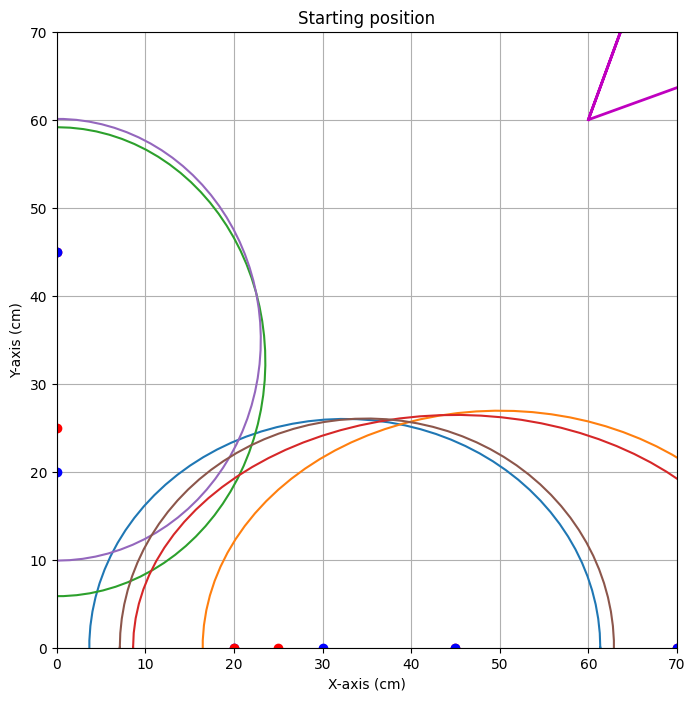


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=79.881


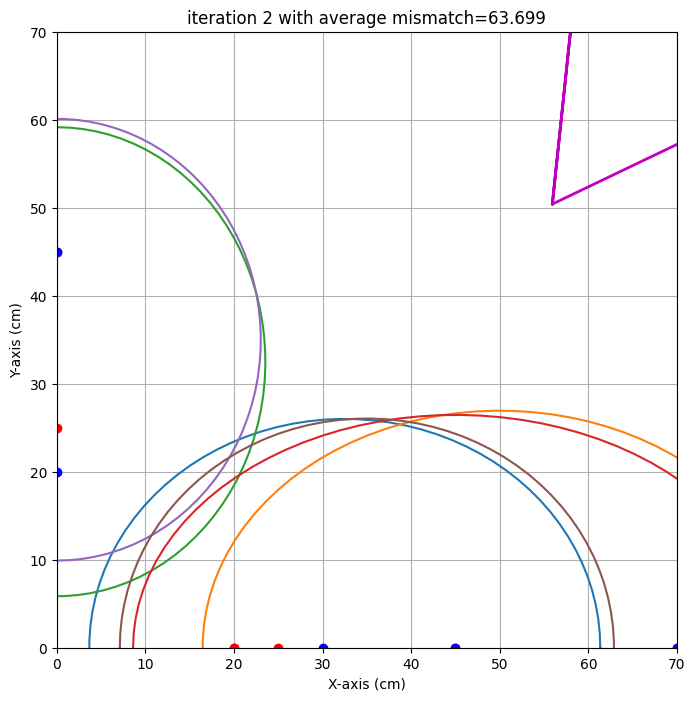

end iteration 2 with average mismatch=63.699


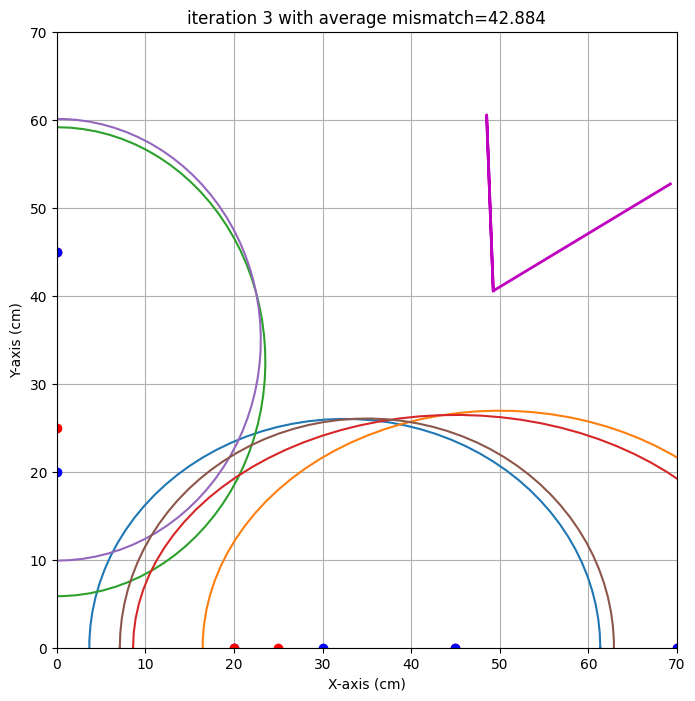

end iteration 3 with average mismatch=42.884


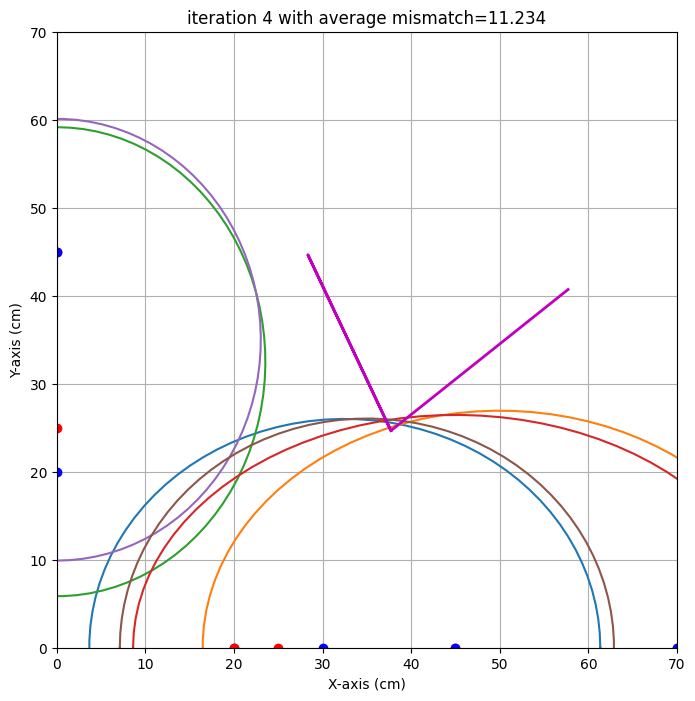

end iteration 4 with average mismatch=11.234


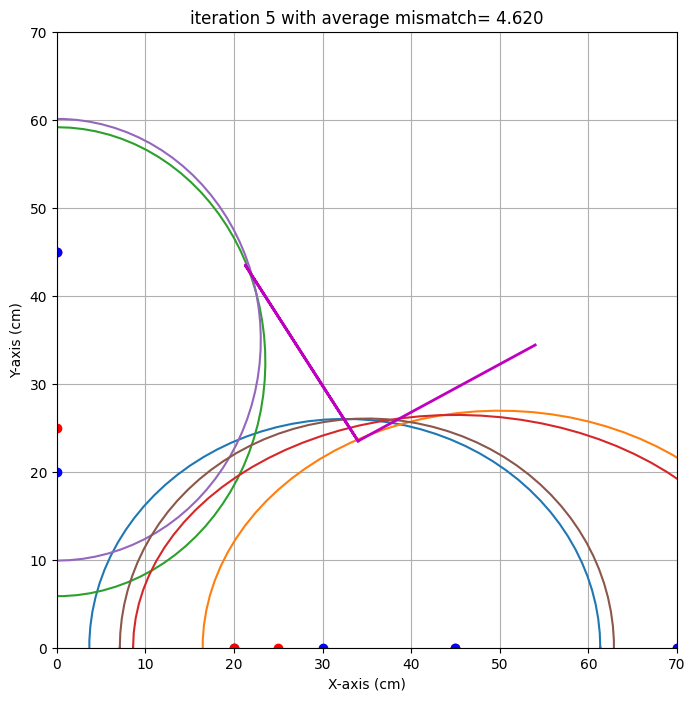

end iteration 5 with average mismatch= 4.620
end iteration 6 with average mismatch= 4.607
end iteration 7 with average mismatch= 4.607


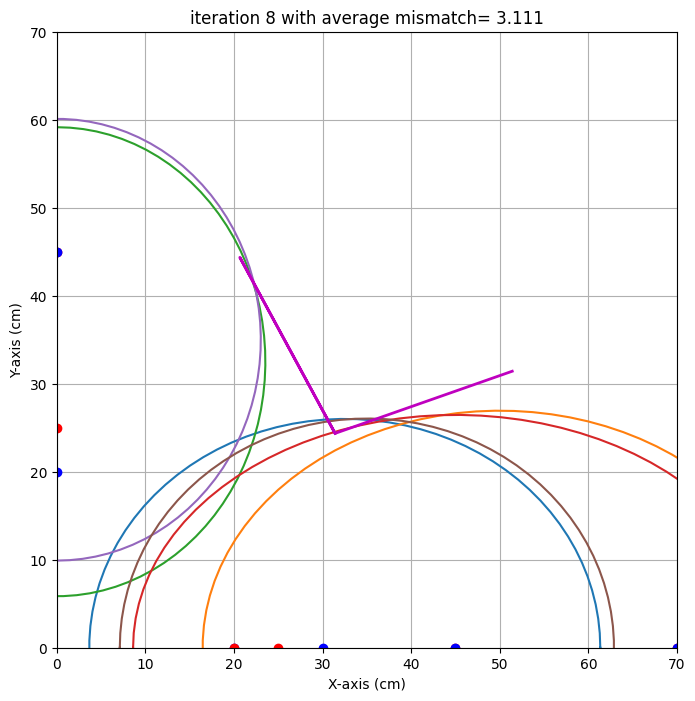

end iteration 8 with average mismatch= 3.111


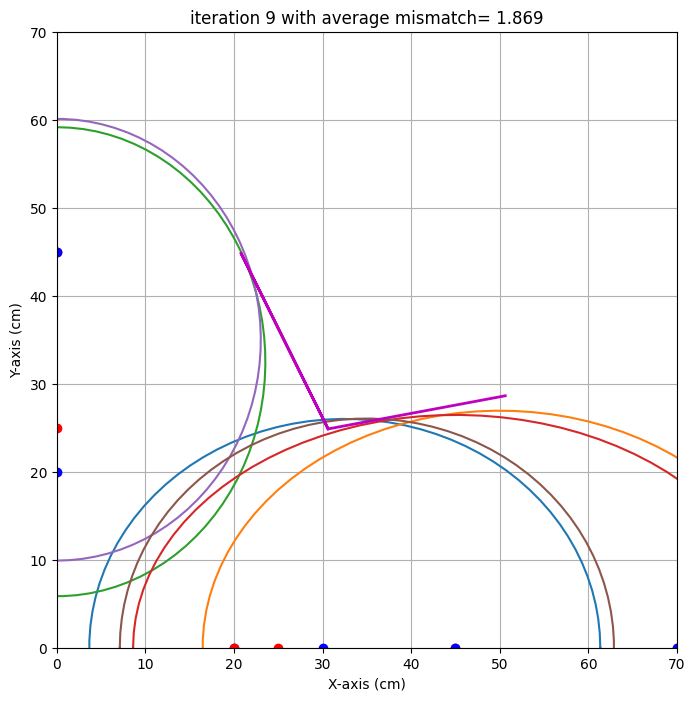

end iteration 9 with average mismatch= 1.869


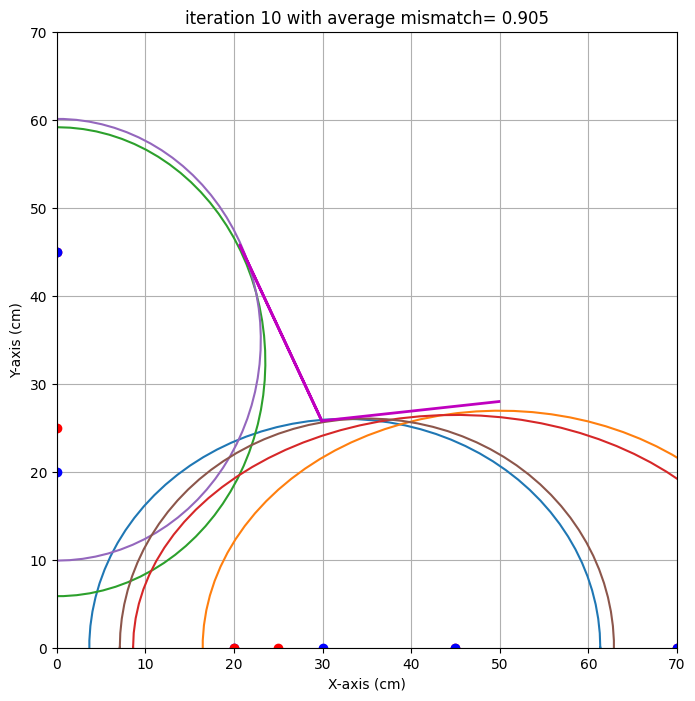

end iteration 10 with average mismatch= 0.905


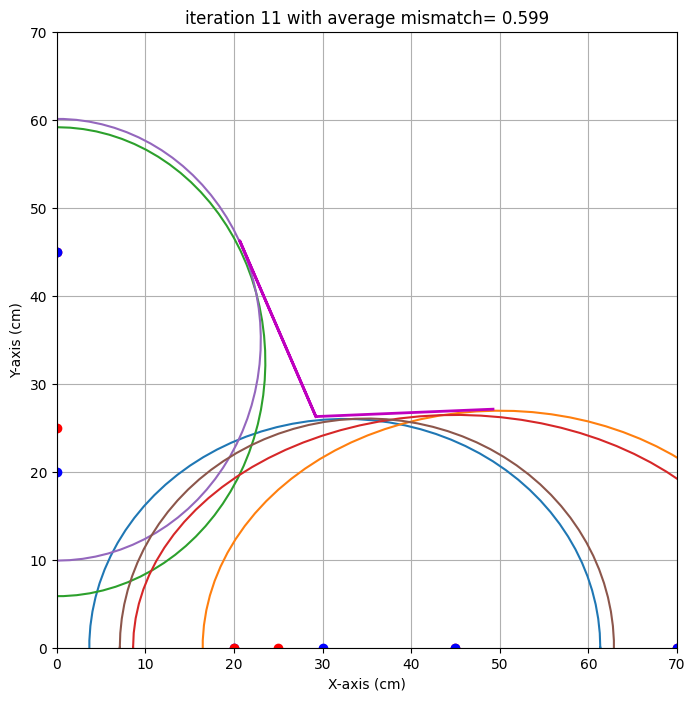

end iteration 11 with average mismatch= 0.599


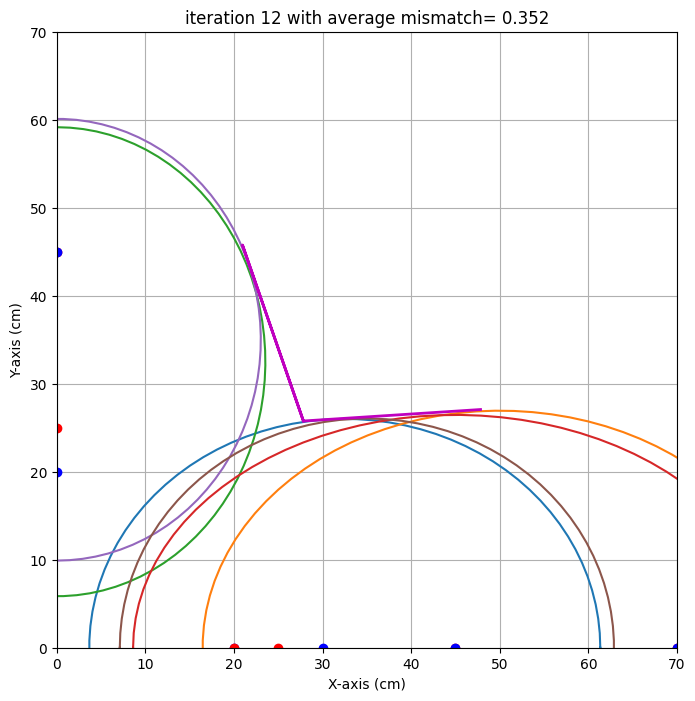

end iteration 12 with average mismatch= 0.352
end iteration 13 with average mismatch= 0.317
end iteration 14 with average mismatch= 0.299
end iteration 15 with average mismatch= 0.299
end iteration 16 with average mismatch= 0.299
end iteration 17 with average mismatch= 0.299
end iteration 18 with average mismatch= 0.299
end iteration 19 with average mismatch= 0.299
end iteration 20 with average mismatch= 0.299
end iteration 21 with average mismatch= 0.299
end iteration 22 with average mismatch= 0.299
end iteration 23 with average mismatch= 0.299
end iteration 24 with average mismatch= 0.299
end iteration 25 with average mismatch= 0.299
end iteration 26 with average mismatch= 0.299
end iteration 27 with average mismatch= 0.299
end iteration 28 with average mismatch= 0.299
end iteration 29 with average mismatch= 0.299
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.299
#################

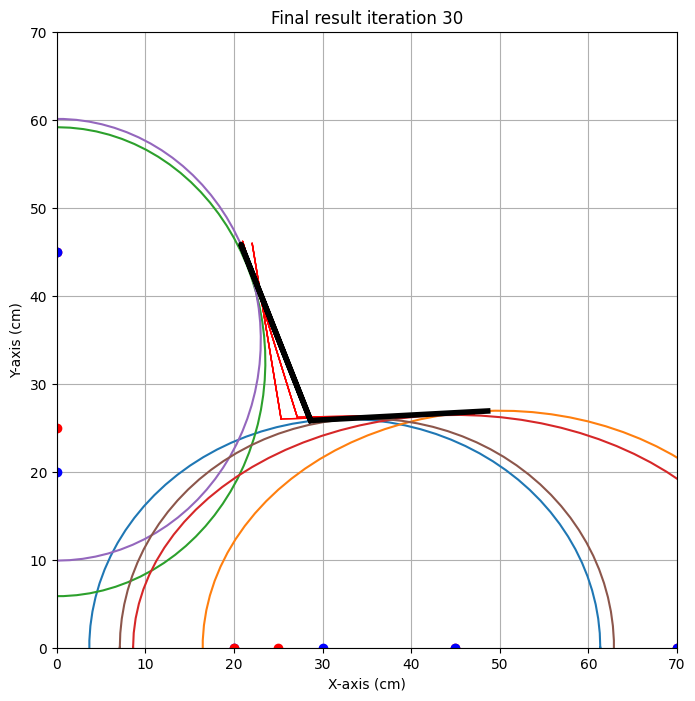

{'alpha': np.float64(3.0848944125323254), 'alpha_eps': np.float64(2.03750746100333), 'beta': np.float64(-21.441790842712486), 'beta_eps': np.float64(12.149207826269308), 'x0': np.float64(28.637982152079193), 'x0_eps': np.float64(3.3259267967606263), 'y0': np.float64(25.823678295868724), 'y0_eps': np.float64(0.3808132024904438)}
test locatie 
x0 target is : 20.0. Gevonden waarde: 28.6 cm met een standaardafwijking van 3.3 cm 
y0 target is : 20.0. Gevonden waarde: 25.8 cm met een standaardafwijking van 0.4 cm 
alpha target is : 13.0. Gevonden waarde: 3.1 graden met een standaardafwijking van 2.0 graad 
beta target is : 1.0. Gevonden waarde: -21.4 graden met een standaardafwijking van 12.1 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  20,
                    'y0':  20,
                    'alpha' :  13,
                    'beta' : 1
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [45, 0, 20, 0, 57.7],
                    #[45, 0, 70, 0, -],
                    [70, 0, 30, 0, 67.1],
                    [0, 45, 0, 20, 53.3],
                    #[0, 45, 0, 70, -],
                    #[0, 70, 0, 30, -]
                    [20, 0, 70, 0, 72.8],
                    #[0, 70, 0, 20, -]
                    [0, 25, 0, 45, 50.2],
                    #,
                    #[0, 50, 0, 65, -],
                    [25, 0, 45, 0, 55.8],
                    #[50, 0, 65, 0, -]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")

Figuur: ![Alt](tudelftLogo.png "Title")